# 서울시 119 이송 건수 · 인구 밀집 — 통합 예측

**흐름**
1. 데이터 불러오기 · 시간순 분할 기준
2. 생활인구 × 이송 건수 연관성 (학습 기간만)
3. 인구 특성 추가 효과 비교 → 메인 모델 사용 여부 자동 결정
4. 이송 건수 예측 (자치구 × 월, 모델 6종 + GradientBoosting·Ridge 앙상블)
   - 정확도 개선 실험 : 달력 특성 · 증감량 예측 → 검증 점수로 자동 결정
5. 인구 밀집 예측 (자치구 × 일, 모델 6종)
6. 결과 요약

**공통 기준**
- 분할 3단계 : 학습 → 검증(모델·특성 고르기) → 평가(성능 보고)
- 모델 6종 : LinearRegression · Ridge · DecisionTree · RandomForest · GradientBoosting · DNN(Keras)
- 정확도 : (1 − MAPE) × 100
- 결과 csv : 자치구 단위 결과는 모두 `지역구명` 컬럼 포함

**사용 파일 (`ml_data`)**

| 파일 | 내용 |
|---|---|
| `transport_dataset.csv` · `features_transport.csv` · `transport_future.csv` | 이송 학습 데이터 · 특성 목록 · 미래 입력 |
| `population_dataset.csv` | 자치구 × 일 생활인구 (전일 값 포함) |
| `population_selected.csv` · `features_population.csv` | 인구 밀집 학습 데이터 · 특성 목록 |

**결과 파일 (`ml_result`)** : 파일 이름은 이전 버전과 동일

## 0. 환경 설정
- 경로 : `BASE_DIR` 하나만 바꾸면 나머지 폴더가 따라 바뀜
- 한글 폰트 : 운영체제별 폰트 파일 직접 등록 (`addfont`)
- 반복 작업 함수화 : `load_csv` · `save_csv` · `save_fig`

In [1]:
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)


def set_korean_font():
    candidates = [
        'C:/Windows/Fonts/malgun.ttf',                            # Windows
        '/System/Library/Fonts/Supplemental/AppleGothic.ttf',     # macOS
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',        # Linux
    ]
    for path in candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
            return
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
        if name in installed:
            plt.rcParams['font.family'] = name
            return


set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

TEST_MONTHS, VALID_MONTHS = 6, 6          # 이송 : 평가 6개월, 그 앞 검증 6개월
POP_TEST_DAYS, POP_VALID_DAYS = 365, 180  # 인구 : 평가 1년, 그 앞 검증 180일
POP_CORR_MIN = 0.30                       # 인구 특성 선택 기준 |상관계수|
TOP_N = 8                                 # 그래프에 그릴 상위 자치구 수

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GU_LIST = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
           '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
           '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
MODEL_NAMES = ['LinearRegression', 'Ridge', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'DNN']
COMPARE_MODELS = ['LinearRegression', 'RandomForest', 'GradientBoosting']   # 특성 조합 비교용

ENSEMBLE_NAME = 'Ensemble(GB+Ridge)'
ENSEMBLE_MEMBERS = ['GradientBoosting', 'Ridge']
TRANSPORT_MODELS = MODEL_NAMES + [ENSEMBLE_NAME]


def load_csv(name, dates=True):
    return pd.read_csv(ML_DATA_DIR / name, encoding='utf-8-sig', parse_dates=['ds'] if dates else None)


def save_csv(df, name, index=False):
    df.to_csv(RESULT_DIR / name, index=index, encoding='utf-8-sig')


def save_fig(name):
    plt.tight_layout()
    plt.savefig(RESULT_DIR / name, bbox_inches='tight')
    plt.show()

## 0-1. 공통 함수
- `fit_model` : 스케일러 + 모델을 한 묶음(dict)으로 학습
  - `StandardScaler` : 학습 데이터에만 fit (평가 데이터 정보 누출 방지)
  - DNN : Dense → BatchNormalization → Dropout, L2 규제, he_normal 초기화
  - DNN 콜백 : EarlyStopping · ReduceLROnPlateau
  - DNN `validation_split=0.2` : 입력의 마지막 20% 행 → 입력은 날짜순이어야 함
  - 앙상블 : 구성 모델을 각각 학습해 `members`에 보관
- `predict` : 앙상블이면 구성 모델 예측의 평균
- `evaluate` : 정확도(%) · R2 · MAE · RMSE
- `make_X` : 숫자 특성 + 원-핫(카테고리 고정 → 학습·평가·미래 입력 컬럼 항상 동일)
- `split` : 날짜 기준 학습 · 검증 · 학습+검증 · 평가 분할
- `group_importance` : 원-핫 컬럼 중요도 합산
- `plot_test_result` · `plot_top_trend` : 평가 결과 · 상위 자치구 추이 그래프
- 모델 저장 : pickle(머신러닝), h5(DNN)

In [2]:
DNN_SETTINGS = {
    'transport':  {'units': [64, 32],      'epochs': 500, 'batch_size': 32,  'patience': 30},
    'population': {'units': [128, 64, 32], 'epochs': 100, 'batch_size': 256, 'patience': 10},
}


def make_ml_model(name, topic):
    t = topic == 'transport'
    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=0.8 if t else 1.0),
        'DecisionTree': DecisionTreeRegressor(max_depth=6 if t else 10, min_samples_leaf=5 if t else 10,
                                              random_state=SEED),
        'RandomForest': RandomForestRegressor(n_estimators=300 if t else 100, max_depth=10 if t else 15,
                                              n_jobs=-1, random_state=SEED),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=300 if t else 200, max_depth=3 if t else 4,
                                                      learning_rate=0.05 if t else 0.1, random_state=SEED),
    }
    return models[name]


def build_dnn(n_features, units):
    model = Sequential([Input(shape=(n_features,))])
    for u in units:
        model.add(Dense(u, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model


def fit_model(name, X, y, topic):
    if name == ENSEMBLE_NAME:
        return {'name': name, 'members': [fit_model(m, X, y, topic) for m in ENSEMBLE_MEMBERS]}

    x_scaler = StandardScaler().fit(X)
    Xs = x_scaler.transform(X)
    bundle = {'name': name, 'x_scaler': x_scaler, 'columns': list(X.columns)}

    if name == 'DNN':
        s = DNN_SETTINGS[topic]
        y_scaler = StandardScaler().fit(y.values.reshape(-1, 1))
        model = build_dnn(Xs.shape[1], s['units'])
        callbacks = [EarlyStopping(monitor='val_loss', patience=s['patience'], restore_best_weights=True),
                     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=s['patience'] // 2, min_lr=1e-6)]
        hist = model.fit(Xs, y_scaler.transform(y.values.reshape(-1, 1)), epochs=s['epochs'],
                         batch_size=s['batch_size'], validation_split=0.2, callbacks=callbacks, verbose=0)
        bundle.update({'y_scaler': y_scaler, 'history': hist.history})
    else:
        model = make_ml_model(name, topic).fit(Xs, y)

    bundle['model'] = model
    return bundle


def predict(bundle, X):
    if bundle['name'] == ENSEMBLE_NAME:
        return np.mean([predict(m, X) for m in bundle['members']], axis=0)
    Xs = bundle['x_scaler'].transform(X)
    if bundle['name'] == 'DNN':
        return bundle['y_scaler'].inverse_transform(bundle['model'].predict(Xs, verbose=0)).flatten()
    return bundle['model'].predict(Xs)


def evaluate(y_true, y_pred):
    return {'정확도(%)': (1 - mean_absolute_percentage_error(y_true, y_pred)) * 100,
            'R2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))}


def make_X(df, cols, onehot):
    # onehot : {컬럼명: (카테고리, 접두어)}
    df = df.reset_index(drop=True)
    dummies = [pd.get_dummies(pd.Categorical(df[c], categories=cats), prefix=p, dtype=int)
               for c, (cats, p) in onehot.items()]
    return pd.concat([df[cols]] + dummies, axis=1)


TRANSPORT_ONEHOT = {'District': (GU_LIST, '구'), '월': (range(1, 13), '월')}
POP_ONEHOT = {'District': (GU_LIST, '구'), '요일': (range(7), '요일'), '월': (range(1, 13), '월')}


def split(df, valid_start, test_start):
    return {'train': df[df['ds'] < valid_start].reset_index(drop=True),
            'valid': df[(df['ds'] >= valid_start) & (df['ds'] < test_start)].reset_index(drop=True),
            'train_valid': df[df['ds'] < test_start].reset_index(drop=True),
            'test': df[df['ds'] >= test_start].reset_index(drop=True)}


def group_importance(bundle, prefixes):
    imp = pd.Series(bundle['model'].feature_importances_, index=bundle['columns'])
    for prefix in prefixes:
        cols = [c for c in imp.index if c.startswith(prefix)]
        imp[prefix.rstrip('_') + '(합계)'] = imp[cols].sum()
        imp = imp.drop(cols)
    return imp.sort_values()


def plot_importance(imp, title, ax):
    ax.barh(imp.index, imp.values, color='seagreen')
    ax.set_xlabel('중요도')
    ax.set_title(title)


def plot_history(history, title, file):
    # val_loss가 다시 오르면 과적합 신호
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], 'y', label='train_loss')
    plt.plot(history['val_loss'], 'r', label='val_loss')
    plt.xlabel('epoch')
    plt.title(title)
    plt.legend()
    save_fig(file)


def plot_scores(score_df, cols, best, title, file):
    # 빨강 = 최고 모델, 회색 = 기준선
    fig, axes = plt.subplots(1, len(cols), figsize=(8 * len(cols), 5))
    for ax, col in zip(axes, cols):
        d = score_df.sort_values(col)
        colors = ['gray' if m.startswith('기준선') else 'tomato' if m == best else 'steelblue' for m in d['모델']]
        ax.barh(d['모델'], d[col], color=colors)
        for i, v in enumerate(d[col]):
            ax.text(v, i, f' {v:.2f}%', va='center')
        ax.set_xlim(d[col].min() - 3, 100)
        ax.set_title(f'{title} {col}')
    save_fig(file)


def test_tables(result, real_col, pred_col):
    # 오차율 컬럼 추가 + 자치구별 점수표
    result['오차율(%)'] = ((result[pred_col] - result[real_col]).abs() / result[real_col] * 100).round(2)
    rows = []
    for gu, g in result.groupby('지역구명'):
        s = evaluate(g[real_col], g[pred_col])
        rows.append({'지역구명': gu, '행수': len(g), '실제평균': g[real_col].mean(),
                     '예측평균': g[pred_col].mean(), 'MAE': s['MAE'], '정확도(%)': s['정확도(%)']})
    return result, pd.DataFrame(rows).sort_values('정확도(%)').reset_index(drop=True)


def plot_test_result(result, gu_score, real_col, pred_col, model_name, file, s=20):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.3]})
    axes[0].scatter(result[real_col], result[pred_col], s=s, alpha=0.5)
    lim = [result[real_col].min(), result[real_col].max()]
    axes[0].plot(lim, lim, 'r--')
    axes[0].set_xlabel(real_col)
    axes[0].set_ylabel(pred_col)
    axes[0].set_title(f'실제 vs 예측 ({model_name})')
    axes[1].barh(gu_score['지역구명'], gu_score['정확도(%)'], color='coral')
    axes[1].set_xlim(gu_score['정확도(%)'].min() - 3, 100)
    axes[1].set_title('자치구별 정확도(%)')
    save_fig(file)


def plot_top_trend(real, pred, gu_list, title, file, marker='o'):
    # real, pred : '지역구명', '날짜', '값' 컬럼
    nrows = int(np.ceil(len(gu_list) / 2))
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows), squeeze=False)
    axes = axes.flatten()
    for ax, gu in zip(axes, gu_list):
        r = real[real['지역구명'] == gu].sort_values('날짜')
        p = pred[pred['지역구명'] == gu].sort_values('날짜')
        ax.plot(r['날짜'], r['값'], marker=marker, markersize=3, label='실제')
        ax.plot(p['날짜'], p['값'], 'r--', marker=marker and 's', markersize=3, label='예측')
        ax.set_title(gu)
        ax.tick_params(axis='x', rotation=30)
        ax.legend()
    for ax in axes[len(gu_list):]:
        ax.remove()
    fig.suptitle(title)
    save_fig(file)


def save_bundle(bundle, prefix):
    # DNN : 모델은 h5, 나머지는 pickle / 머신러닝 : 묶음 전체 pickle
    if bundle['name'] == 'DNN':
        save_model(bundle['model'], RESULT_DIR / f'{prefix}_best_model.h5')
        bundle = {k: v for k, v in bundle.items() if k != 'model'}
    with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
        pickle.dump(bundle, f)


def load_bundle(prefix):
    with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'rb') as f:
        bundle = pickle.load(f)
    if bundle['name'] == 'DNN':
        bundle['model'] = load_model(RESULT_DIR / f'{prefix}_best_model.h5')
    return bundle

---
# 1. 데이터 불러오기 · 분할 기준
- 분할 기준 날짜를 **여기서 한 번만** 정하고 2~4장이 모두 같이 사용
  - 학습 : 검증 시작 전까지 → 연관성 분석·이송률 계산도 이 기간만
  - 검증 : 평가 직전 `VALID_MONTHS`개월 → **고르기**에만 사용
  - 평가 : 마지막 `TEST_MONTHS`개월 → **성능 보고**에만 사용
- 무작위 분할(`train_test_split`) 미사용 : 미래 데이터가 학습에 섞이는 것 방지

In [3]:
target = 'transport_cnt'

full = load_csv('transport_dataset.csv')
future = load_csv('transport_future.csv')
population = load_csv('population_dataset.csv')
feat_info = load_csv('features_transport.csv', dates=False)
num_features = feat_info.loc[feat_info['결과'] == '선택', '컬럼'].tolist()

months = sorted(full.dropna(subset=[target])['ds'].unique())
test_start = pd.Timestamp(months[-TEST_MONTHS])
valid_start = pd.Timestamp(months[-(TEST_MONTHS + VALID_MONTHS)])

print('선택 특성 :', num_features)
print('검증 시작 :', valid_start.date(), '/ 평가 시작 :', test_start.date())

선택 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']
검증 시작 : 2025-01-01 / 평가 시작 : 2025-07-01


---
# 2. 생활인구 × 이송 건수 연관성 (학습 기간만)

**핵심 개념**
- 자치구 간 비교 : 구별 평균끼리 → "큰 구가 이송도 많은가"
- 자치구 내 비교 : 한 구 안에서 → "인구가 늘어난 달에 이송도 늘었는가"

## 2-1. 당월 생활인구 만들기
- 이송 데이터에는 **전월** 인구만 있음 → 같은 달 관계 확인에 당월 인구 필요
- `전일_` 컬럼을 하루 앞 날짜로 이동 → 그날의 실제 값
- 일별 값 → 월평균 (`groupby` + `mean`)
- 기간 제한 : 검증 시작 전까지

**인구 컬럼 뜻** : `total_pop` 총생활인구 · `day_pop` 주간 · `night_pop` 야간(거주 인구에 가까움) · `pop_diff` 주간 − 야간

In [4]:
prev_cols = [c for c in population.columns if c.startswith('전일_')]
daily = population[['ds', 'District'] + prev_cols].copy()
daily.columns = ['ds', 'District'] + [c.replace('전일_', '') for c in prev_cols]
POP_COLS = daily.columns[2:].tolist()
daily['ds'] = (daily['ds'] - pd.Timedelta(days=1)).dt.to_period('M').dt.to_timestamp()   # 하루 앞 → 그 달 1일

pop_month = daily.groupby(['ds', 'District'], as_index=False)[POP_COLS].mean()
rel = full[['ds', 'District', '월', target]].merge(pop_month, on=['ds', 'District'])
rel = rel[rel['ds'] < valid_start].dropna(subset=[target]).sort_values(['District', 'ds']).reset_index(drop=True)
print('인구 컬럼 :', POP_COLS)

인구 컬럼 : ['total_pop', '내국인생활인구수', '장기체류외국인인구수', '단기체류외국인인구수', '일최대인구수', '일최소인구수', 'day_pop', 'night_pop', '일최대이동인구수', '서울외유입인구수', '동일자치구행정동간이동인구수', '자치구간이동인구수', 'pop_diff']


## 2-2. 산점도 · 상관 분석 (4가지 관점)
- 왼쪽 : 구 × 월 전체 / 오른쪽 : 구별 평균 (점 25개)
- 점들이 구별로 뭉쳐 있으면 → 상관이 "구 규모"에서 나온 것
- 상관 관점
  - 전체 (피어슨 / 스피어만) · 자치구 간 (구별 평균, n=25)
  - 자치구 내 : 구 평균을 뺀 값끼리
  - 자치구 내 (계절 제거) : 구·월 평균을 뺀 값끼리

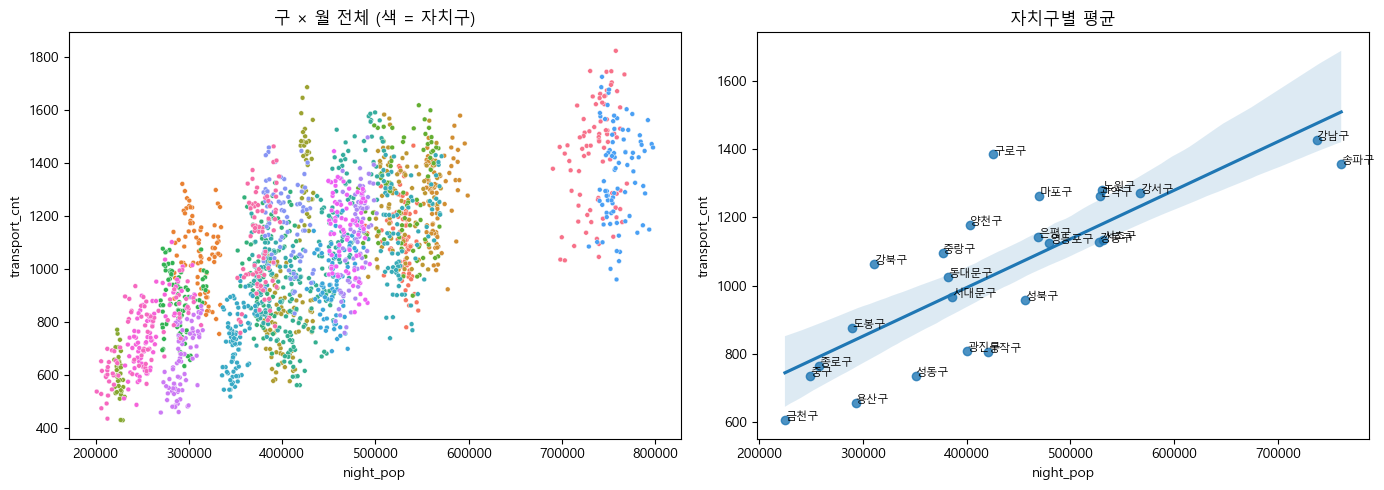

,전체_피어슨,전체_스피어만,자치구간,자치구내,자치구내_계절제거
night_pop,0.694,0.699,0.804,0.230,0.306
동일자치구행정동간이동인구수,0.644,0.656,0.777,0.005,0.017
일최소인구수,0.656,0.667,0.773,0.110,0.188
내국인생활인구수,0.660,0.686,0.762,0.195,0.273
total_pop,0.650,0.663,0.751,0.241,0.319
일최대인구수,0.599,0.623,0.681,0.315,0.385
day_pop,0.552,0.569,0.635,0.240,0.317
일최대이동인구수,0.407,0.331,0.452,0.275,0.349
서울외유입인구수,0.344,0.205,0.364,0.364,0.467
자치구간이동인구수,0.136,-0.016,0.140,0.314,0.392


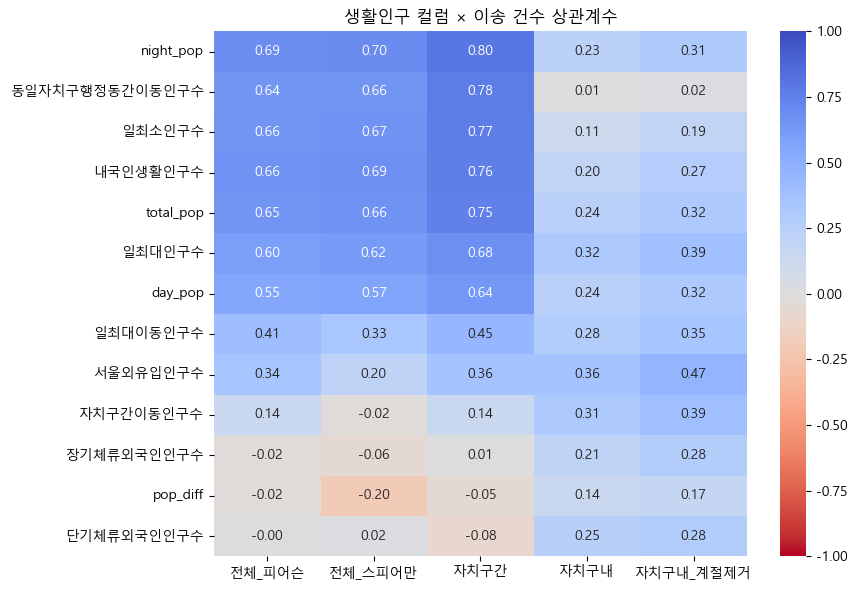

In [5]:
district_mean = rel.groupby('District')[POP_COLS + [target]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=rel, x='night_pop', y=target, hue='District', legend=False, s=12, ax=axes[0])
axes[0].set_title('구 × 월 전체 (색 = 자치구)')
sns.regplot(data=district_mean, x='night_pop', y=target, ax=axes[1])
for gu, row in district_mean.iterrows():
    axes[1].text(row['night_pop'], row[target], gu, fontsize=8)
axes[1].set_title('자치구별 평균')
save_fig('relation_scatter.png')

cols = POP_COLS + [target]
within = rel[cols] - rel.groupby('District')[cols].transform('mean')
within_season = rel[cols] - rel.groupby(['District', '월'])[cols].transform('mean')
within_season['District'] = rel['District']

rel_corr = pd.DataFrame({
    '전체_피어슨': rel[POP_COLS].corrwith(rel[target]),
    '전체_스피어만': rel[POP_COLS].corrwith(rel[target], method='spearman'),
    '자치구간': district_mean[POP_COLS].corrwith(district_mean[target]),
    '자치구내': within[POP_COLS].corrwith(within[target]),
    '자치구내_계절제거': within_season[POP_COLS].corrwith(within_season[target]),
}).round(3).sort_values('자치구간', ascending=False)
display(rel_corr)

plt.figure(figsize=(9, 6))
sns.heatmap(rel_corr, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.title('생활인구 컬럼 × 이송 건수 상관계수')
save_fig('relation_corr_heatmap.png')

## 2-3. 대표 인구 컬럼 · 유의성 검정 · 인구 1만명당 이송률
- 대표 컬럼 : 자치구 간 상관이 가장 높은 컬럼
- `pearsonr` : 상관계수 + p-value (≤ 0.05 → 통계적으로 의미 있음)
- 이송률 : 구별 월평균 이송 건수 ÷ 대표 인구 × 10,000
- 이송률 차이가 크면 → 인구만으로는 부족, 구별 "이송률" 정보 필요

대표 인구 컬럼 : night_pop
전체         r =  0.694, p-value = 0.0000, n = 1933
자치구간       r =  0.804, p-value = 0.0000, n = 25
자치구내       r =  0.230, p-value = 0.0000, n = 1933
자치구내_계절제거  r =  0.306, p-value = 0.0000, n = 1933
이송률 최고/최저 비율 : 1.91배


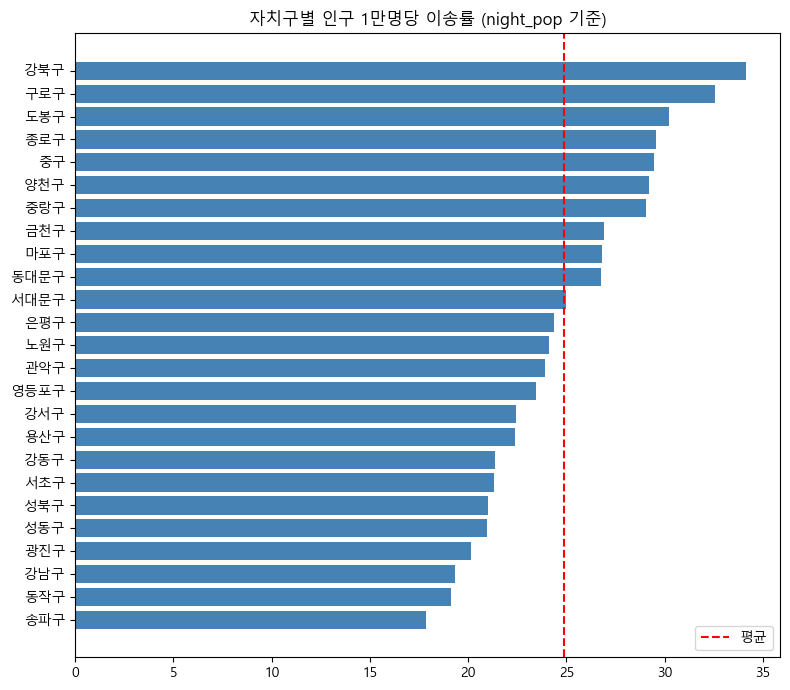

In [6]:
KEY_POP = rel_corr['자치구간'].idxmax()
print('대표 인구 컬럼 :', KEY_POP)
for name, d in [('전체', rel), ('자치구간', district_mean), ('자치구내', within), ('자치구내_계절제거', within_season)]:
    r, p = pearsonr(d[KEY_POP], d[target])
    print(f'{name:10s} r = {r:6.3f}, p-value = {p:.4f}, n = {len(d)}')

district_rate = pd.DataFrame({'월평균_이송건수': district_mean[target], '월평균_인구': district_mean[KEY_POP]})
district_rate['인구1만명당_이송률'] = district_rate['월평균_이송건수'] / district_rate['월평균_인구'] * 10000
district_rate = district_rate.sort_values('인구1만명당_이송률')
rate_ratio = district_rate['인구1만명당_이송률'].max() / district_rate['인구1만명당_이송률'].min()
print(f'이송률 최고/최저 비율 : {rate_ratio:.2f}배')

plt.figure(figsize=(8, 7))
plt.barh(district_rate.index, district_rate['인구1만명당_이송률'], color='steelblue')
plt.axvline(district_rate['인구1만명당_이송률'].mean(), c='r', linestyle='--', label='평균')
plt.title(f'자치구별 인구 1만명당 이송률 ({KEY_POP} 기준)')
plt.legend()
save_fig('relation_district_rate.png')

## 2-4. 시계열 분해 · 시차
- `seasonal_decompose` : 실제값 = 추세 + 계절성 + 잔차 (`period=12`)
- 같은 성분끼리 상관 : 추세(장기 흐름) · 계절(패턴 방향) · 잔차(갑작스러운 변화)
- 준비 조건 : 빈 달 없이 연속 (`asfreq('MS')` + 보간), 최소 24개월
- 표준화 비교 : (값 − 평균) / 표준편차 → 단위가 달라도 겹쳐 보기
- 시차 : 이번 달 / 1·2·3개월 전 인구 중 이송과 가장 가까운 것 (`shift`)

,구 평균
원본_상관,0.19
추세_상관,0.17
계절_상관,-0.40
잔차_상관,0.17


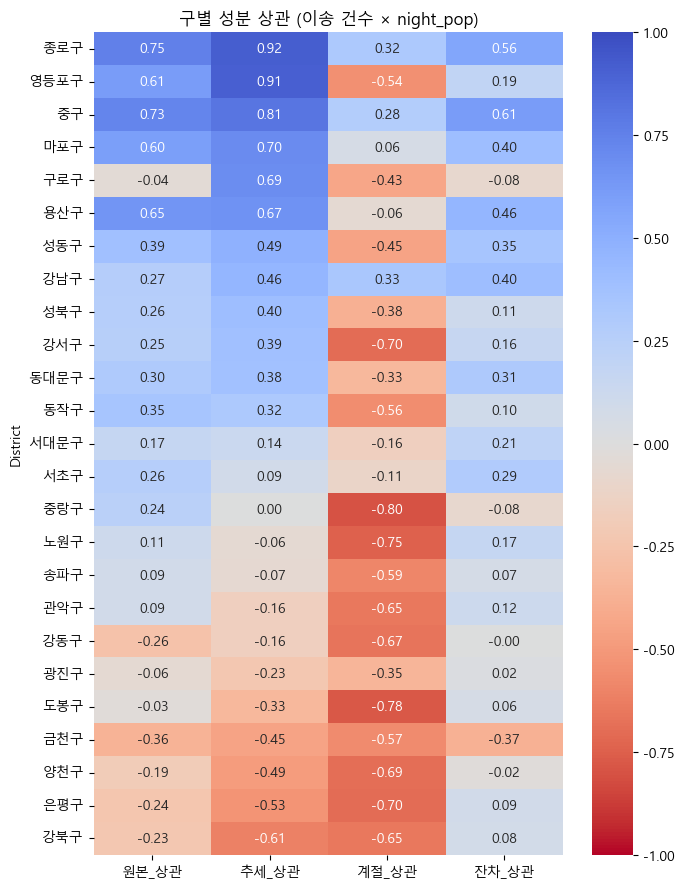

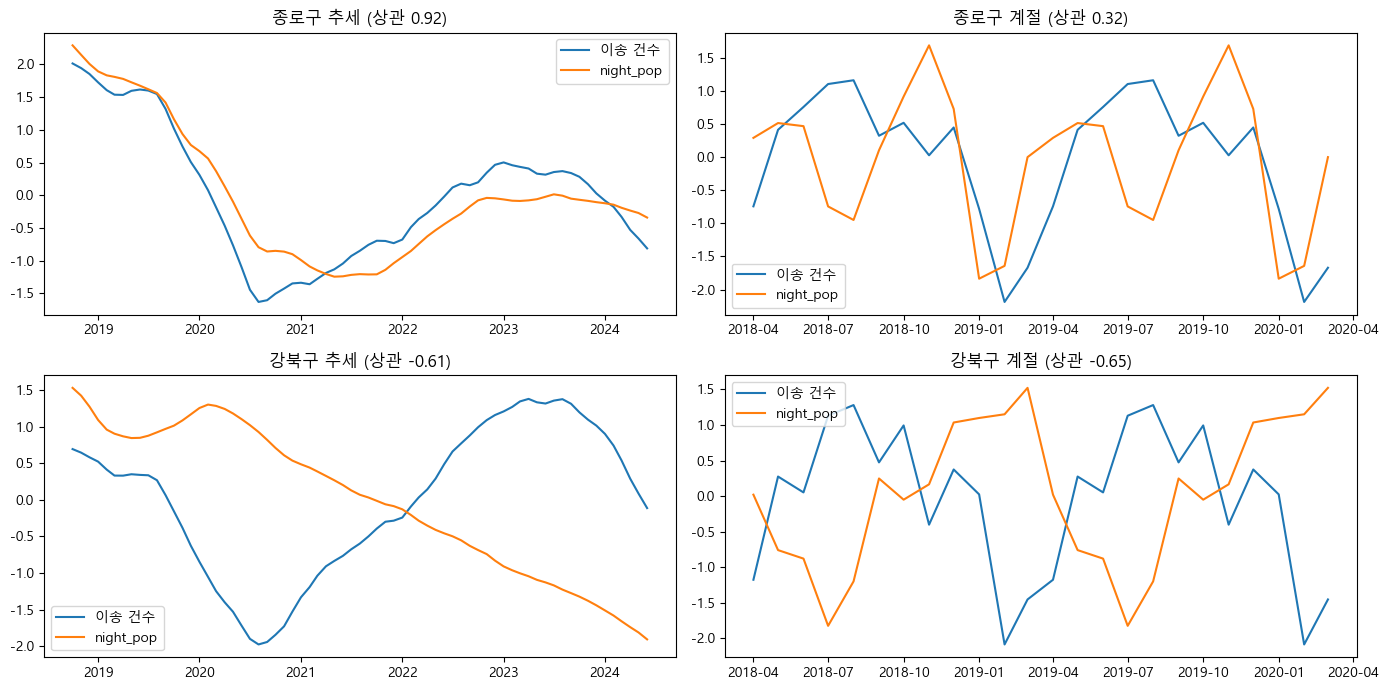

,transport_cnt,night_pop,이송_증감률(%),인구_증감률(%)
ds,,,,
2018,27430.0,10687556.0,NaN,NaN
2019,26035.0,10469265.0,-5.1,-2.0
2020,20650.0,10275724.0,-20.7,-1.8
2021,21597.0,9988877.0,4.6,-2.8
2022,27143.0,10641313.0,25.7,6.5
2023,28442.0,10663715.0,4.8,0.2
2024,23686.0,10562199.0,-16.7,-1.0


,시차(개월),상관계수
0,0,0.306
1,1,0.261
2,2,0.216
3,3,0.163


In [7]:
decomp_rows, decomp_result = [], {}
for gu, g in rel.groupby('District'):
    s = g.set_index('ds')[[target, KEY_POP]].asfreq('MS').interpolate()
    if len(s) < 24:   # 2년 미만이면 분해 불가
        continue
    rt = seasonal_decompose(s[target], period=12)
    rp = seasonal_decompose(s[KEY_POP], period=12)
    decomp_result[gu] = (rt, rp)
    decomp_rows.append({'District': gu, '원본_상관': s[target].corr(s[KEY_POP]),
                        '추세_상관': rt.trend.corr(rp.trend), '계절_상관': rt.seasonal.corr(rp.seasonal),
                        '잔차_상관': rt.resid.corr(rp.resid)})

decomp_corr = pd.DataFrame(decomp_rows).set_index('District').round(2).sort_values('추세_상관', ascending=False)
display(decomp_corr.mean().round(2).to_frame('구 평균'))

plt.figure(figsize=(7, 9))
sns.heatmap(decomp_corr, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.title(f'구별 성분 상관 (이송 건수 × {KEY_POP})')
save_fig('relation_decompose_corr.png')

zscore = lambda s: (s - s.mean()) / s.std()

# 추세 상관 최고 구 vs 최저 구
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for i, gu in enumerate([decomp_corr.index[0], decomp_corr.index[-1]]):
    rt, rp = decomp_result[gu]
    for j, (part, label, n) in enumerate([('trend', '추세', None), ('seasonal', '계절', 24)]):
        axes[i, j].plot(zscore(getattr(rt, part))[:n], label='이송 건수')
        axes[i, j].plot(zscore(getattr(rp, part))[:n], label=KEY_POP)
        axes[i, j].set_title(f'{gu} {label} (상관 {decomp_corr.loc[gu, label + "_상관"]:.2f})')
        axes[i, j].legend()
save_fig('relation_trend_compare.png')

# 연도별 서울 전체 흐름
city = rel.groupby('ds')[[target, KEY_POP]].sum()
yearly = city.groupby(city.index.year).mean()
change = (yearly.pct_change() * 100).round(1)
change.columns = ['이송_증감률(%)', '인구_증감률(%)']
display(pd.concat([yearly.round(0), change], axis=1))

# 시차 확인 (자치구 내, 계절 제거 값 기준)
lag_table = pd.DataFrame([
    {'시차(개월)': lag,
     '상관계수': round(within_season.groupby('District')[KEY_POP].shift(lag).corr(within_season[target]), 3)}
    for lag in [0, 1, 2, 3]])
display(lag_table)

---
# 3. 인구 특성 추가 효과 비교

## 3-1. 모델용 인구 특성 선택 · 인구 기반 특성
- 후보 : `전월_` 생활인구 컬럼 (예측 시점에 알 수 있는 값)
- 선택 기준 : 학습 기간 |상관계수| ≥ `POP_CORR_MIN`
- `구별_이송률` : 학습 기간 "이송 건수 ÷ 전월 인구" 구별 평균 (타깃 인코딩 원리)
- `인구기반_예상` : 구별_이송률 × 전월 인구 → 모델에는 이것만 사용 (`구별_이송률`은 `구_` 원-핫과 정보 동일)

In [8]:
pop_candidates = [c for c in full.columns if c.startswith('전월_') and ('pop' in c or '인구' in c)]
train_rows = full[full['ds'] < valid_start]

pop_corr = train_rows[pop_candidates].corrwith(train_rows[target]).sort_values(key=abs, ascending=False)
pop_select = pd.DataFrame({'Pearson_r': pop_corr.round(4), '선택': pop_corr.abs() >= POP_CORR_MIN})
POP_FEATURES = pop_select.index[pop_select['선택']].tolist() or [pop_corr.index[0]]
display(pop_select)

KEY_POP_PREV = '전월_' + KEY_POP if '전월_' + KEY_POP in full.columns else '전월_night_pop'
rate_map = (train_rows[target] / train_rows[KEY_POP_PREV]).groupby(train_rows['District']).mean()
for df in (full, future):
    df['구별_이송률'] = df['District'].map(rate_map)
    df['인구기반_예상'] = df['구별_이송률'] * df[KEY_POP_PREV]

print('선택된 인구 특성 :', POP_FEATURES, '/ 이송률 기준 :', KEY_POP_PREV)

,Pearson_r,선택
전월_night_pop,0.6925,True
전월_내국인생활인구수,0.6586,True
전월_일최소인구수,0.6542,True
전월_동일자치구행정동간이동인구수,0.6487,True
전월_total_pop,0.6479,True
전월_일최대인구수,0.5971,True
전월_day_pop,0.5495,True
전월_일최대이동인구수,0.4068,True
전월_서울외유입인구수,0.3400,True
전월_자치구간이동인구수,0.1368,False


선택된 인구 특성 : ['전월_night_pop', '전월_내국인생활인구수', '전월_일최소인구수', '전월_동일자치구행정동간이동인구수', '전월_total_pop', '전월_일최대인구수', '전월_day_pop', '전월_일최대이동인구수', '전월_서울외유입인구수'] / 이송률 기준 : 전월_night_pop


## 3-2. 특성 조합 5가지 비교
- 모든 조합에 `구_`·`월_` 원-핫 포함
- A 계절 / B +인구 / C +인구+이송률 / D +이송이력 / E 전체(D + 인구 + 인구기반_예상)
- 비교 포인트 : A→B→C (이송 기록 없을 때 인구 효과) / D→E (이송 기록 있을 때 추가 효과)
- 같은 행 비교 : 모든 조합에 필요한 값이 있는 행만 사용
- 기준선 : "이번 달 = 지난달"

,특성조합,모델,검증_정확도(%),평가_정확도(%),평가_R2,평가_MAE
0,A_계절,LinearRegression,84.391,88.963,0.704,101.273
1,A_계절,RandomForest,80.684,90.102,0.755,88.954
2,A_계절,GradientBoosting,82.957,88.917,0.730,97.715
3,B_계절+인구,LinearRegression,83.369,89.400,0.721,96.475
4,B_계절+인구,RandomForest,85.831,93.477,0.897,59.552
5,B_계절+인구,GradientBoosting,87.211,92.960,0.863,65.300
6,C_계절+인구+이송률,LinearRegression,83.292,89.348,0.718,96.969
7,C_계절+인구+이송률,RandomForest,87.402,93.572,0.890,60.045
8,C_계절+인구+이송률,GradientBoosting,88.034,92.900,0.862,66.025
9,D_계절+이송이력,LinearRegression,94.335,94.572,0.926,50.033


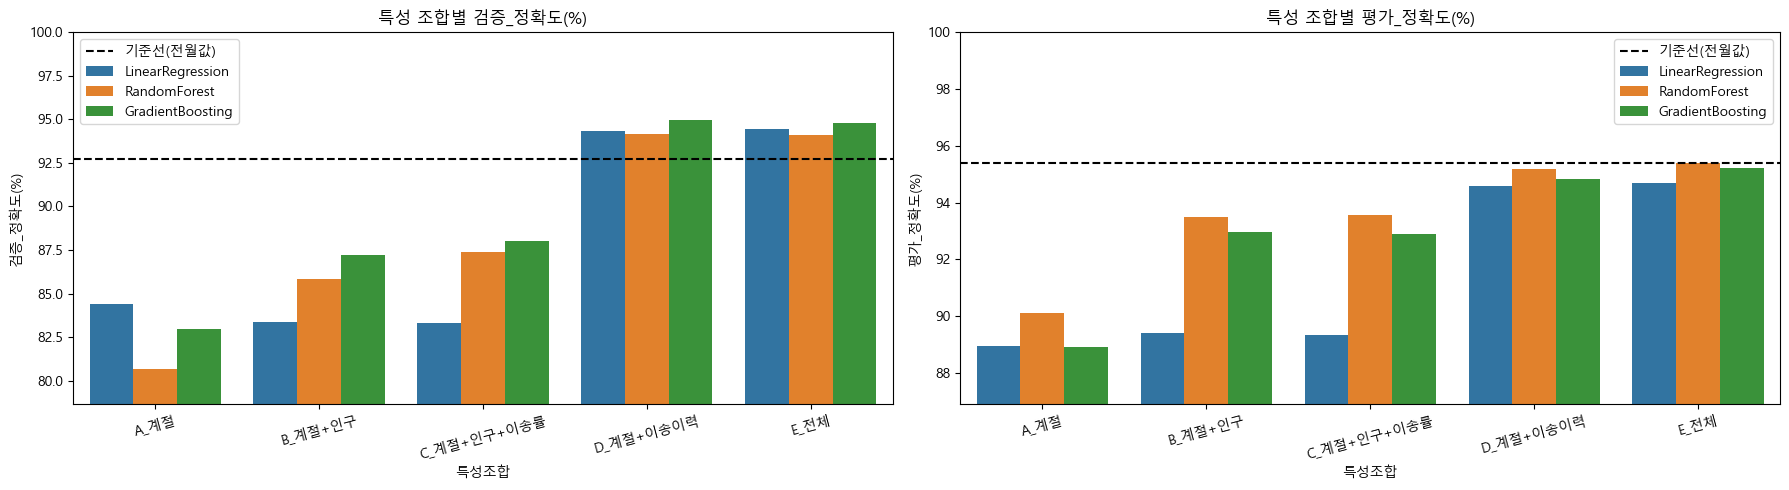

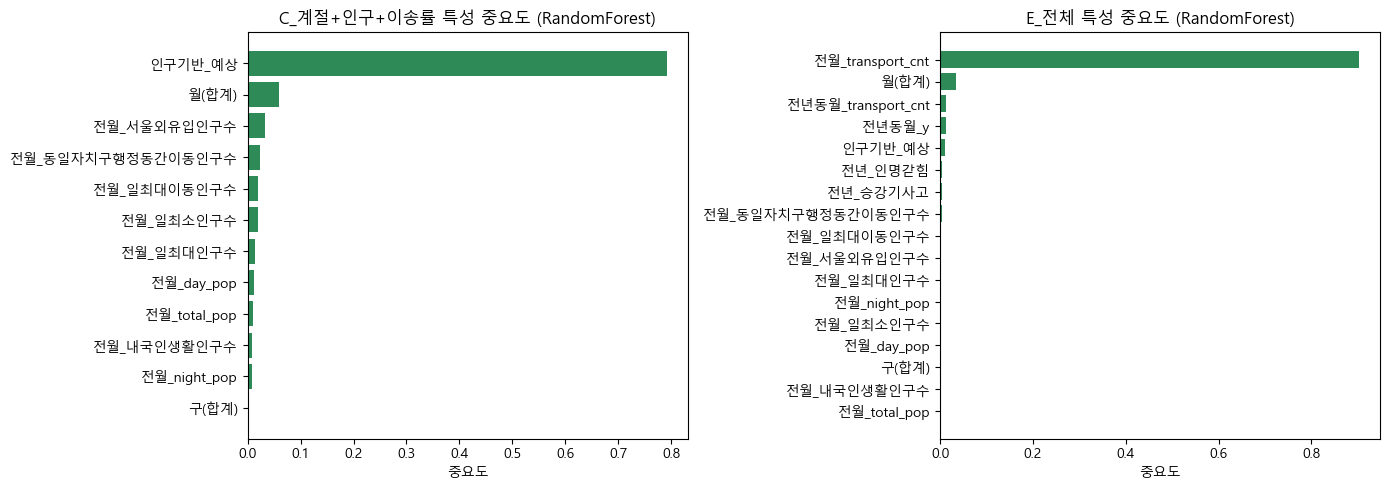

In [9]:
HISTORY = [c for c in ['전월_transport_cnt', '전년동월_transport_cnt', '전년동월_y', '전년_인명갇힘', '전년_승강기사고']
           if c in full.columns]
FEATURE_SETS = {
    'A_계절': [],
    'B_계절+인구': POP_FEATURES,
    'C_계절+인구+이송률': POP_FEATURES + ['인구기반_예상'],
    'D_계절+이송이력': HISTORY,
    'E_전체': HISTORY + POP_FEATURES + ['인구기반_예상'],
}
all_cols = sorted(set(sum(FEATURE_SETS.values(), [])))
cmp = split(full.dropna(subset=all_cols + [target]).sort_values(['ds', 'District']), valid_start, test_start)


def score_row(v, t, **name):
    return {**name, '검증_정확도(%)': v['정확도(%)'], '평가_정확도(%)': t['정확도(%)'],
            '평가_R2': t['R2'], '평가_MAE': t['MAE']}


cmp_rows, cmp_bundles = [], {}
for set_name, cols in FEATURE_SETS.items():
    for name in COMPARE_MODELS:
        scores = []
        for fit_part, eval_part in [('train', 'valid'), ('train_valid', 'test')]:
            b = fit_model(name, make_X(cmp[fit_part], cols, TRANSPORT_ONEHOT), cmp[fit_part][target], 'transport')
            scores.append(evaluate(cmp[eval_part][target], predict(b, make_X(cmp[eval_part], cols, TRANSPORT_ONEHOT))))
        cmp_bundles[(set_name, name)] = b
        cmp_rows.append(score_row(*scores, 특성조합=set_name, 모델=name))

base = [evaluate(cmp[p][target], cmp[p]['전월_transport_cnt']) for p in ['valid', 'test']]
cmp_rows.append(score_row(*base, 특성조합='기준선(전월값)', 모델='-'))
cmp_score = pd.DataFrame(cmp_rows)
display(cmp_score.round(3))

model_rows = cmp_score[cmp_score['모델'] != '-']
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, col in zip(axes, ['검증_정확도(%)', '평가_정확도(%)']):
    sns.barplot(data=model_rows, x='특성조합', y=col, hue='모델', ax=ax)
    ax.axhline(cmp_score[col].iloc[-1], c='k', linestyle='--', label='기준선(전월값)')
    ax.set_ylim(cmp_score[col].min() - 2, 100)
    ax.set_title(f'특성 조합별 {col}')
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
save_fig('relation_model_compare.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, set_name in zip(axes, ['C_계절+인구+이송률', 'E_전체']):
    plot_importance(group_importance(cmp_bundles[(set_name, 'RandomForest')], ['구_', '월_']),
                    f'{set_name} 특성 중요도 (RandomForest)', ax)
save_fig('relation_feature_importance.png')

## 3-3. 메인 모델에 인구 특성 사용 여부 결정 · 저장
- 결정 기준 : **검증** 정확도에서 E가 D보다 높을 때만 추가
- 추가 조건 : 미래 입력에도 그 값이 모두 있어야 함 (없으면 미래 예측 불가)

In [10]:
best_valid = cmp_score.groupby('특성조합')['검증_정확도(%)'].max()
pop_gain = best_valid['E_전체'] - best_valid['D_계절+이송이력']
add_cols = [c for c in POP_FEATURES + ['인구기반_예상'] if c not in num_features]
USE_POP = bool(add_cols) and pop_gain > 0 and future.reindex(columns=add_cols).notna().all().all()
if USE_POP:
    num_features = num_features + add_cols
print(f'인구 특성 사용 : {USE_POP} (검증 정확도 {pop_gain:+.3f}%p) / 메인 모델 특성 : {num_features}')

save_csv(rel_corr, 'relation_corr_table.csv', index=True)
save_csv(district_rate.join(decomp_corr).reset_index().rename(columns={'District': '지역구명'}).round(3),
         'relation_district_rate.csv')
save_csv(pop_select, 'relation_pop_feature_select.csv', index=True)
save_csv(cmp_score, 'relation_model_compare.csv')
full[[c for c in full.columns if c != target] + [target]].to_csv(
    ML_DATA_DIR / 'transport_pop_features.csv', index=False, encoding='utf-8-sig')

인구 특성 사용 : False (검증 정확도 -0.177%p) / 메인 모델 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']


---
# 4. 이송 건수 예측 (자치구 × 월)

## 4-0. 달력 특성
- `월_` 원-핫은 "몇 월인가"만 알려 줌 → 해마다 다른 달력 차이 보완
  - 예) 설 연휴가 1월인 해 vs 2월인 해, 윤년 2월, 주말이 5번인 달
- 특성 4종 : `일수` · `주말수` · `평일공휴일수` · `명절연휴일수`(설·추석 전날·당일·다음날)
- 공휴일 표 : 양력 공휴일 + 음력 공휴일(설날·추석·석가탄신일) 연도별 직접 입력
  - 미포함 : 대체공휴일, 선거일, 임시공휴일 (월 단위라 영향 작음)
- 미래 입력에도 같은 방식으로 계산

In [11]:
FIXED_HOLIDAYS = ['01-01', '03-01', '05-05', '06-06', '08-15', '10-03', '12-25']
# 연도: (설날, 추석, 석가탄신일)
LUNAR_HOLIDAYS = {
    2005: ('2005-02-09', '2005-09-18', '2005-05-15'), 2006: ('2006-01-29', '2006-10-06', '2006-05-05'),
    2007: ('2007-02-18', '2007-09-25', '2007-05-24'), 2008: ('2008-02-07', '2008-09-14', '2008-05-12'),
    2009: ('2009-01-26', '2009-10-03', '2009-05-02'), 2010: ('2010-02-14', '2010-09-22', '2010-05-21'),
    2011: ('2011-02-03', '2011-09-12', '2011-05-10'), 2012: ('2012-01-23', '2012-09-30', '2012-05-28'),
    2013: ('2013-02-10', '2013-09-19', '2013-05-17'), 2014: ('2014-01-31', '2014-09-08', '2014-05-06'),
    2015: ('2015-02-19', '2015-09-27', '2015-05-25'), 2016: ('2016-02-08', '2016-09-15', '2016-05-14'),
    2017: ('2017-01-28', '2017-10-04', '2017-05-03'), 2018: ('2018-02-16', '2018-09-24', '2018-05-22'),
    2019: ('2019-02-05', '2019-09-13', '2019-05-12'), 2020: ('2020-01-25', '2020-10-01', '2020-04-30'),
    2021: ('2021-02-12', '2021-09-21', '2021-05-19'), 2022: ('2022-02-01', '2022-09-10', '2022-05-08'),
    2023: ('2023-01-22', '2023-09-29', '2023-05-27'), 2024: ('2024-02-10', '2024-09-17', '2024-05-15'),
    2025: ('2025-01-29', '2025-10-06', '2025-05-05'), 2026: ('2026-02-17', '2026-09-25', '2026-05-24'),
    2027: ('2027-02-07', '2027-09-15', '2027-05-13'),
}
CAL_FEATURES = ['일수', '주말수', '평일공휴일수', '명절연휴일수']


def holiday_dates(year):
    # 반환 : (전체 공휴일, 명절 연휴)
    days = [pd.Timestamp(f'{year}-{md}') for md in FIXED_HOLIDAYS]
    if year <= 2007:
        days.append(pd.Timestamp(f'{year}-07-17'))   # 제헌절 (2008년부터 제외)
    if year >= 2013:
        days.append(pd.Timestamp(f'{year}-10-09'))   # 한글날 (2013년부터 다시 공휴일)
    festive = []
    if year in LUNAR_HOLIDAYS:
        seol, chuseok, buddha = map(pd.Timestamp, LUNAR_HOLIDAYS[year])
        festive = [d + pd.Timedelta(days=k) for d in (seol, chuseok) for k in (-1, 0, 1)]
        days += festive + [buddha]
    return set(days), set(festive)


def month_calendar(m):
    holi, festive = holiday_dates(m.year)
    days = pd.date_range(m, m + pd.offsets.MonthEnd(0))
    weekend = days.dayofweek >= 5
    return {'일수': len(days), '주말수': int(weekend.sum()),
            '평일공휴일수': sum(d in holi and not w for d, w in zip(days, weekend)),
            '명절연휴일수': sum(d in festive for d in days)}


cal_all = pd.DataFrame({m: month_calendar(m) for m in sorted(set(full['ds']) | set(future['ds']))}).T
cal_all.index.name = 'ds'
full = full.join(cal_all, on='ds')
future = future.join(cal_all, on='ds')
save_csv(cal_all, 'transport_calendar.csv', index=True)
display(cal_all.loc[:full['ds'].max()].tail(12))

,일수,주말수,평일공휴일수,명절연휴일수
ds,,,,
2025-01-01,31,8,4,3
2025-02-01,28,8,0,0
2025-03-01,31,10,0,0
2025-04-01,30,8,0,0
2025-05-01,31,9,1,0
2025-06-01,30,9,1,0
2025-07-01,31,8,0,0
2025-08-01,31,10,1,0
2025-09-01,30,8,0,0


## 4-1. 학습 데이터 · 분할 · 이송 예측 함수
- 빈 값이 있는 행 제거 (임의 값으로 채우지 않음)
- `fit_transport` : 모델 + 사용 특성 목록 · 증감량 여부를 묶음에 함께 저장
- **증감량 예측** (`diff_target=True`)
  - 정답 : 이번 달 − 지난달, 복원 : 예측 증감량 + 지난달 값
  - 원리 : 트리 모델의 "학습 범위 밖 값 예측 불가" 약점 완화
- `predict_months` : 6개월 재귀 예측 (예측값 → 다음 달 `전월_transport_cnt`)
- `score_transport` : 1개월 · 6개월 점수 / `baseline_transport` : 기준선 점수

In [12]:
data = full.dropna(subset=num_features + [target]).sort_values(['ds', 'District']).reset_index(drop=True)
parts = split(data, valid_start, test_start)
train, valid, train_valid, test = parts.values()
print({k: len(v) for k, v in parts.items()})


def fit_transport(name, df, features, diff_target):
    y = df[target] - df['전월_transport_cnt'] if diff_target else df[target]
    bundle = fit_model(name, make_X(df, features, TRANSPORT_ONEHOT), y, 'transport')
    bundle.update({'features': list(features), 'diff_target': diff_target})
    return bundle


def predict_count(bundle, df):
    pred = predict(bundle, make_X(df, bundle['features'], TRANSPORT_ONEHOT))
    return pred + df['전월_transport_cnt'].values if bundle['diff_target'] else pred


def predict_months(bundle, rows):
    rows = rows.sort_values(['ds', 'District']).reset_index(drop=True)
    out, prev = [], None
    for m in sorted(rows['ds'].unique()):
        part = rows[rows['ds'] == m].copy()
        if prev is not None:
            part['전월_transport_cnt'] = part['District'].map(prev).fillna(part['전월_transport_cnt'])
        part = part.dropna(subset=bundle['features']).reset_index(drop=True)
        part['예측'] = predict_count(bundle, part)
        prev = part.set_index('District')['예측']
        out.append(part)
    return pd.concat(out, ignore_index=True)


def score_transport(bundle, rows):
    rec = predict_months(bundle, rows)
    return evaluate(rows[target], predict_count(bundle, rows)), evaluate(rec[target], rec['예측']), rec


def baseline_transport(rows):
    last = full[full['ds'] < rows['ds'].min()].dropna(subset=[target]).sort_values('ds').groupby('District')[target].last()
    year_ago = evaluate(rows[target], rows['전년동월_transport_cnt'])
    return {'기준선(마지막 달 유지)': (evaluate(rows[target], rows['전월_transport_cnt']),
                                  evaluate(rows[target], rows['District'].map(last))),
            '기준선(전년 동월)': (year_ago, year_ago)}

{'train': 1880, 'valid': 150, 'train_valid': 2030, 'test': 150}


## 4-1-2. 정확도 개선 실험 : 달력 특성 · 증감량 예측
- 설정 4가지 : 기본 / 달력 / 증감량 / 달력+증감량
- 실험 모델 : Ridge · GradientBoosting · RandomForest · 앙상블 (DNN은 시간 문제로 제외)
- 점수 : **학습 → 검증**만 사용
- 결정 기준 : 설정별 최고 검증 6개월 정확도 1위, 단 기본보다 `IMPROVE_MIN`%p 이상 좋아야 채택

설정,기본,달력,증감량,달력+증감량
모델,,,,
Ensemble(GB+Ridge),93.885,94.612,94.226,94.470
GradientBoosting,93.426,94.354,93.571,91.747
RandomForest,92.497,92.510,93.663,87.228
Ridge,93.089,92.734,93.128,92.790


채택 설정 : 달력 (기본 대비 최고 +0.727%p) / 메인 모델 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수', '일수', '주말수', '평일공휴일수', '명절연휴일수']


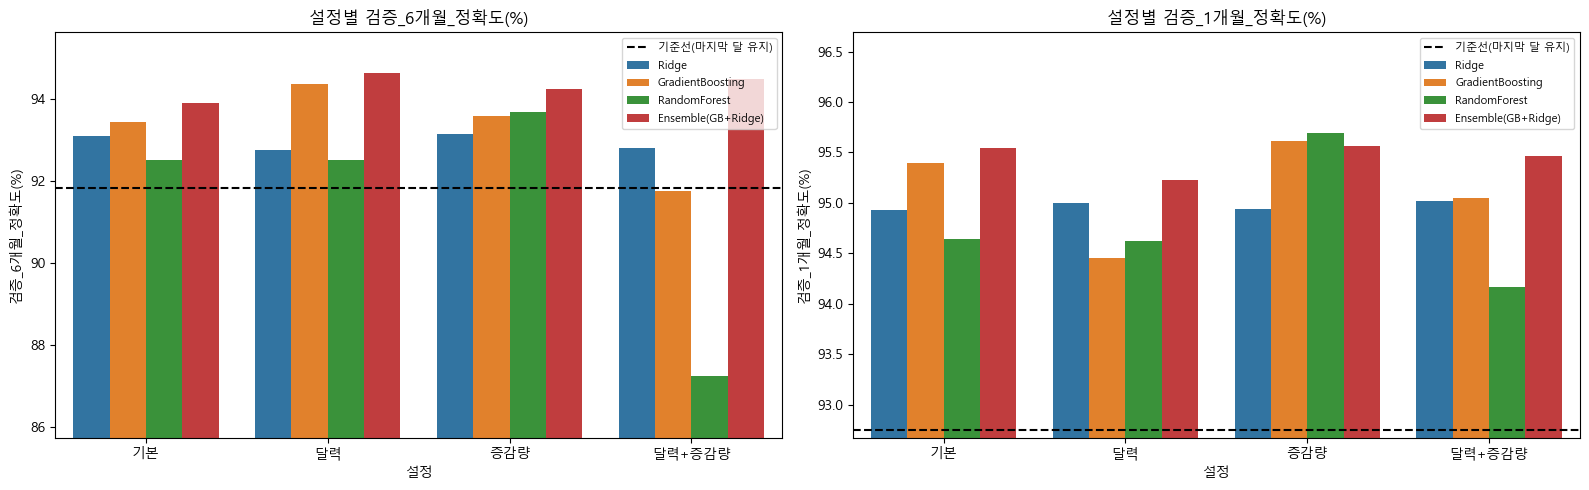

In [13]:
IMPROVE_MIN = 0.10
EXP_MODELS = ['Ridge', 'GradientBoosting', 'RandomForest', ENSEMBLE_NAME]
EXP_SETTINGS = {'기본': (False, False), '달력': (True, False), '증감량': (False, True), '달력+증감량': (True, True)}

exp_rows = []
for set_name, (use_cal, use_diff) in EXP_SETTINGS.items():
    for name in EXP_MODELS:
        one, six, _ = score_transport(fit_transport(name, train, num_features + (CAL_FEATURES if use_cal else []), use_diff), valid)
        exp_rows.append({'설정': set_name, '모델': name, '검증_6개월_정확도(%)': six['정확도(%)'],
                         '검증_6개월_MAE': six['MAE'], '검증_1개월_정확도(%)': one['정확도(%)'],
                         '검증_1개월_MAE': one['MAE']})
exp_df = pd.DataFrame(exp_rows)
save_csv(exp_df.round(3), 'transport_improve_experiment.csv')
display(exp_df.pivot(index='모델', columns='설정', values='검증_6개월_정확도(%)')[list(EXP_SETTINGS)].round(3))

best_by_set = exp_df.groupby('설정')['검증_6개월_정확도(%)'].max()[list(EXP_SETTINGS)]
best_set = best_by_set.idxmax()
gain = best_by_set[best_set] - best_by_set['기본']
if gain < IMPROVE_MIN:
    best_set = '기본'
USE_CALENDAR, USE_DIFF_TARGET = EXP_SETTINGS[best_set]
if USE_CALENDAR:
    num_features = num_features + CAL_FEATURES
print(f'채택 설정 : {best_set} (기본 대비 최고 {gain:+.3f}%p) / 메인 모델 특성 : {num_features}')

base_valid = baseline_transport(valid)['기준선(마지막 달 유지)']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, base in zip(axes, ['검증_6개월_정확도(%)', '검증_1개월_정확도(%)'], [base_valid[1], base_valid[0]]):
    sns.barplot(data=exp_df, x='설정', y=col, hue='모델', order=list(EXP_SETTINGS), ax=ax)
    ax.axhline(base['정확도(%)'], c='k', linestyle='--', label='기준선(마지막 달 유지)')
    ax.set_ylim(exp_df[col].min() - 1.5, min(100, exp_df[col].max() + 1))
    ax.set_title(f'설정별 {col}')
    ax.legend(fontsize=8)
save_fig('transport_improve_experiment.png')

## 4-2. 모델 6종 + 앙상블 비교 · 성능 평가표
- **1개월 예측** : 실제 지난달 값을 알고 다음 달만 예측
- **6개월 연속 예측** : 이번 달 예측값 → 다음 달 `전월_transport_cnt` (재귀 예측)
- **앙상블** : GradientBoosting(구·월 조합 효과) + Ridge(직선 관계, 범위 밖 추세) 예측 평균 → 오차 상쇄
- 진행 : 학습 → 검증 점수 / 학습+검증 → 평가 점수 / 최고 모델 = **검증** 6개월 정확도 1위
- 성능 평가표 : 모델 × 구간(검증·평가) × 방식(1개월·6개월) × 지표 4종
  - R2 : 실제 변동 설명 정도 / MAE : 평균 몇 건 차이 / RMSE : 크게 틀린 달에 벌점
  - 기준선 대비 MAE 개선율(%) : (기준선 MAE − 모델 MAE) ÷ 기준선 MAE × 100

,모델,검증_6개월_정확도(%),평가_6개월_정확도(%),평가_6개월_MAE,평가_1개월_정확도(%),평가_1개월_R2
0,Ensemble(GB+Ridge),94.612,94.593,51.762,94.621,0.923
1,GradientBoosting,94.354,93.267,62.062,95.002,0.934
2,LinearRegression,92.778,87.872,111.230,92.187,0.835
3,Ridge,92.734,94.271,54.196,93.595,0.892
4,RandomForest,92.510,93.984,54.684,95.600,0.944
5,기준선(마지막 달 유지),91.819,93.252,66.353,95.409,0.932
6,DecisionTree,91.449,92.760,66.464,95.304,0.936
7,DNN,88.956,91.818,73.374,93.493,0.888
8,기준선(전년 동월),87.482,90.680,90.853,90.680,0.775


최고 모델 (검증 6개월 기준) : Ensemble(GB+Ridge)


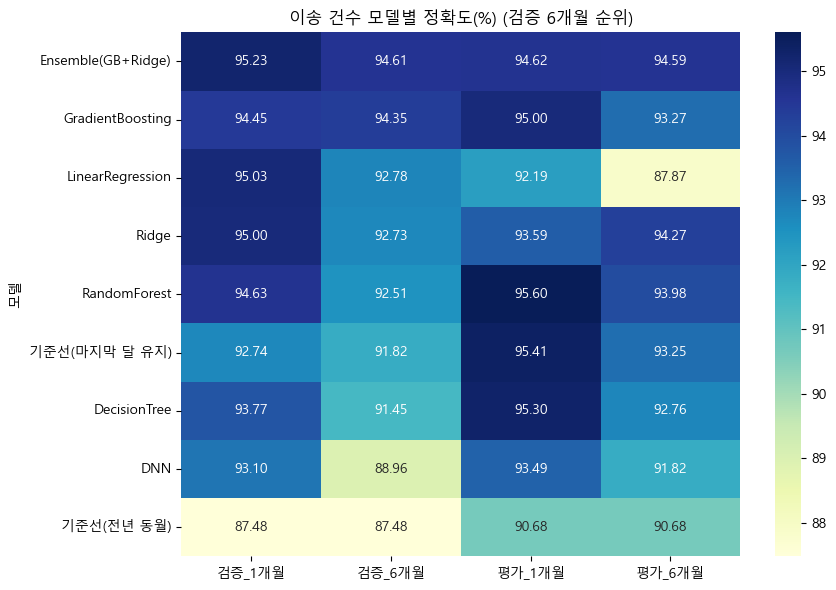

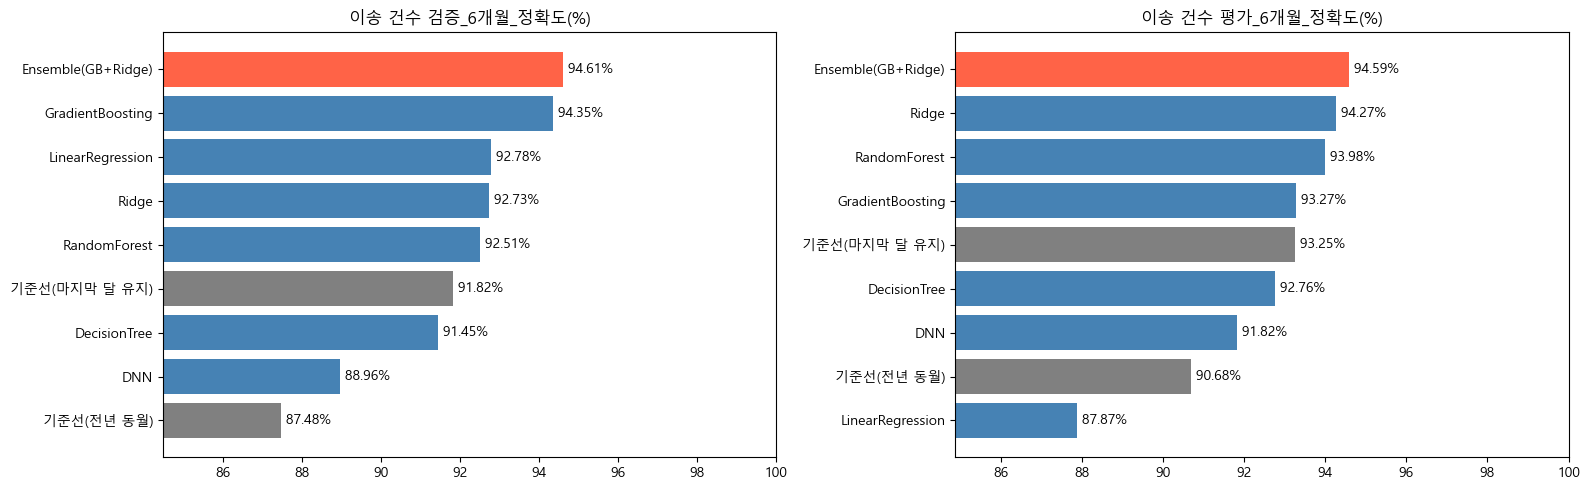

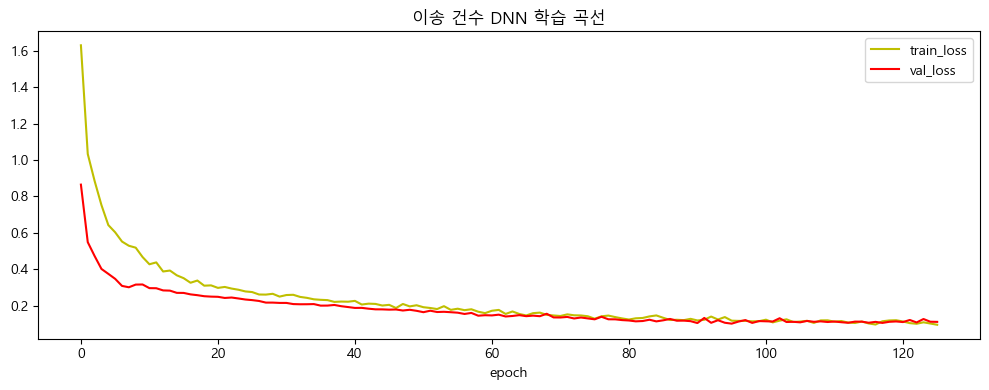

In [14]:
detail_rows, bundles, rec_preds, valid_recs = [], {}, {}, {}


def add_detail(model, part, one, six):
    for how, s in [('1개월', one), ('6개월', six)]:
        detail_rows.append({'모델': model, '구간': part, '방식': how, **s})


for name in TRANSPORT_MODELS:
    v_one, v_six, valid_recs[name] = score_transport(fit_transport(name, train, num_features, USE_DIFF_TARGET), valid)
    bundles[name] = fit_transport(name, train_valid, num_features, USE_DIFF_TARGET)
    t_one, t_six, rec_preds[name] = score_transport(bundles[name], test)
    add_detail(name, '검증', v_one, v_six)
    add_detail(name, '평가', t_one, t_six)

for part, rows in [('검증', valid), ('평가', test)]:
    for bname, (one, six) in baseline_transport(rows).items():
        add_detail(bname, part, one, six)

detail = pd.DataFrame(detail_rows)
base_mae = detail[detail['모델'] == '기준선(마지막 달 유지)'].set_index(['구간', '방식'])['MAE']
detail['기준선대비_MAE_개선율(%)'] = (1 - detail['MAE'] / detail.set_index(['구간', '방식']).index.map(base_mae)) * 100
save_csv(detail.round(3), 'transport_model_scores_detail.csv')

# 요약 점수표 (검증 6개월 순위)
wide = detail.pivot_table(index='모델', columns=['구간', '방식'], values=['정확도(%)', 'MAE', 'R2'])
score_df = pd.DataFrame({'검증_6개월_정확도(%)': wide[('정확도(%)', '검증', '6개월')],
                         '평가_6개월_정확도(%)': wide[('정확도(%)', '평가', '6개월')],
                         '평가_6개월_MAE': wide[('MAE', '평가', '6개월')],
                         '평가_1개월_정확도(%)': wide[('정확도(%)', '평가', '1개월')],
                         '평가_1개월_R2': wide[('R2', '평가', '1개월')]})
score_df = score_df.sort_values('검증_6개월_정확도(%)', ascending=False).reset_index()
save_csv(score_df, 'transport_model_scores.csv')
display(score_df.round(3))

best_name = score_df[score_df['모델'].isin(TRANSPORT_MODELS)].iloc[0]['모델']
best_rec = rec_preds[best_name]
print('최고 모델 (검증 6개월 기준) :', best_name)

acc_map = wide['정확도(%)'].sort_values(('검증', '6개월'), ascending=False)
acc_map.columns = [f'{p}_{h}' for p, h in acc_map.columns]
plt.figure(figsize=(9, 6))
sns.heatmap(acc_map, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('이송 건수 모델별 정확도(%) (검증 6개월 순위)')
save_fig('transport_model_scores_detail.png')

plot_scores(score_df, ['검증_6개월_정확도(%)', '평가_6개월_정확도(%)'], best_name,
            '이송 건수', 'transport_model_scores.png')
plot_history(bundles['DNN']['history'], '이송 건수 DNN 학습 곡선', 'transport_dnn_history.png')

## 4-2-1. 앙상블 효과 확인
- 오차 상관 : 두 모델의 (예측 − 실제) 끼리의 상관 (검증 6개월)
  - 1에 가까움 → 같은 방향으로 틀림 → 평균 효과 작음 / 낮을수록 → 상쇄 효과 큼
- 판단 : 앙상블 검증 점수가 두 구성 모델보다 모두 높으면 효과 있음

,검증_정확도(%),평가_정확도(%),검증_MAE,평가_MAE
모델,,,,
Ensemble(GB+Ridge),94.61,94.59,43.66,51.76
GradientBoosting,94.35,93.27,46.52,62.06
Ridge,92.73,94.27,60.11,54.20
기준선(마지막 달 유지),91.82,93.25,65.45,66.35


오차 상관 0.500 / 앙상블 - 더 좋은 구성 모델 = +0.259%p → 효과 있음


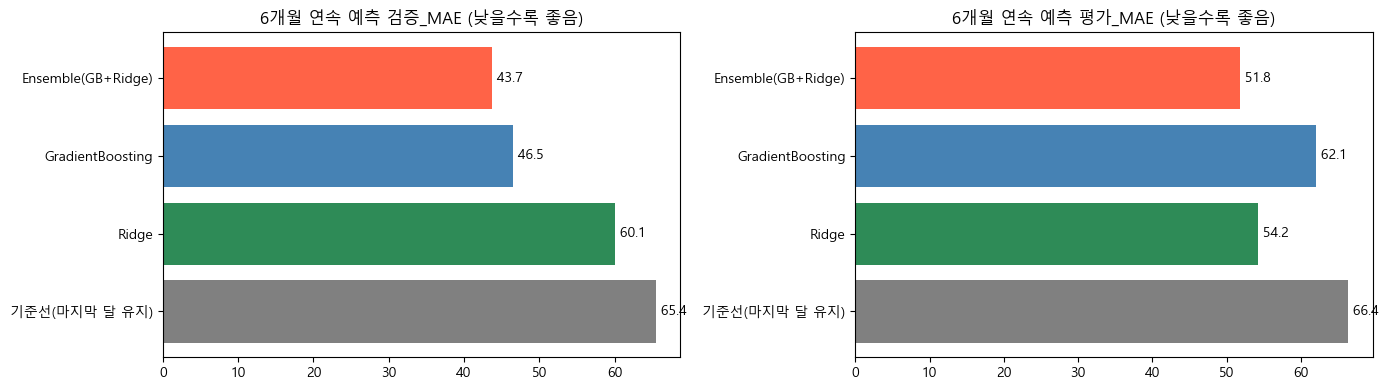

In [15]:
gb, rd = ENSEMBLE_MEMBERS
pair = valid_recs[gb].merge(valid_recs[rd][['ds', 'District', '예측']], on=['ds', 'District'], suffixes=('_gb', '_rd'))
err_corr = (pair['예측_gb'] - pair[target]).corr(pair['예측_rd'] - pair[target])

ens_models = [ENSEMBLE_NAME, gb, rd, '기준선(마지막 달 유지)']
ens_cmp = wide.loc[ens_models, [('정확도(%)', '검증', '6개월'), ('정확도(%)', '평가', '6개월'),
                                ('MAE', '검증', '6개월'), ('MAE', '평가', '6개월')]]
ens_cmp.columns = ['검증_정확도(%)', '평가_정확도(%)', '검증_MAE', '평가_MAE']
save_csv(ens_cmp.round(3), 'transport_ensemble_compare.csv', index=True)
display(ens_cmp.round(2))
ens_gain = ens_cmp.loc[ENSEMBLE_NAME, '검증_정확도(%)'] - ens_cmp.loc[[gb, rd], '검증_정확도(%)'].max()
print(f'오차 상관 {err_corr:.3f} / 앙상블 - 더 좋은 구성 모델 = {ens_gain:+.3f}%p → 효과 {"있음" if ens_gain > 0 else "없음"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['검증_MAE', '평가_MAE']):
    ax.barh(ens_cmp.index, ens_cmp[col], color=['tomato', 'steelblue', 'seagreen', 'gray'])
    for i, v in enumerate(ens_cmp[col]):
        ax.text(v, i, f' {v:.1f}', va='center')
    ax.invert_yaxis()
    ax.set_title(f'6개월 연속 예측 {col} (낮을수록 좋음)')
save_fig('transport_ensemble_compare.png')

## 4-3. 평가 기간 결과 · 특성 중요도
- 산점도 : 대각선(y=x)에 가까울수록 정확
- 추이 그래프 : 파란 실선 = 실제, 빨간 점선 = 예측
- 중요도 기준 : 최고 모델 (앙상블이면 GradientBoosting, 선형·DNN이면 RandomForest로 대신 표시)
  - 원리 : 해당 컬럼으로 나눴을 때 오차가 줄어든 양의 합 (합계 1)

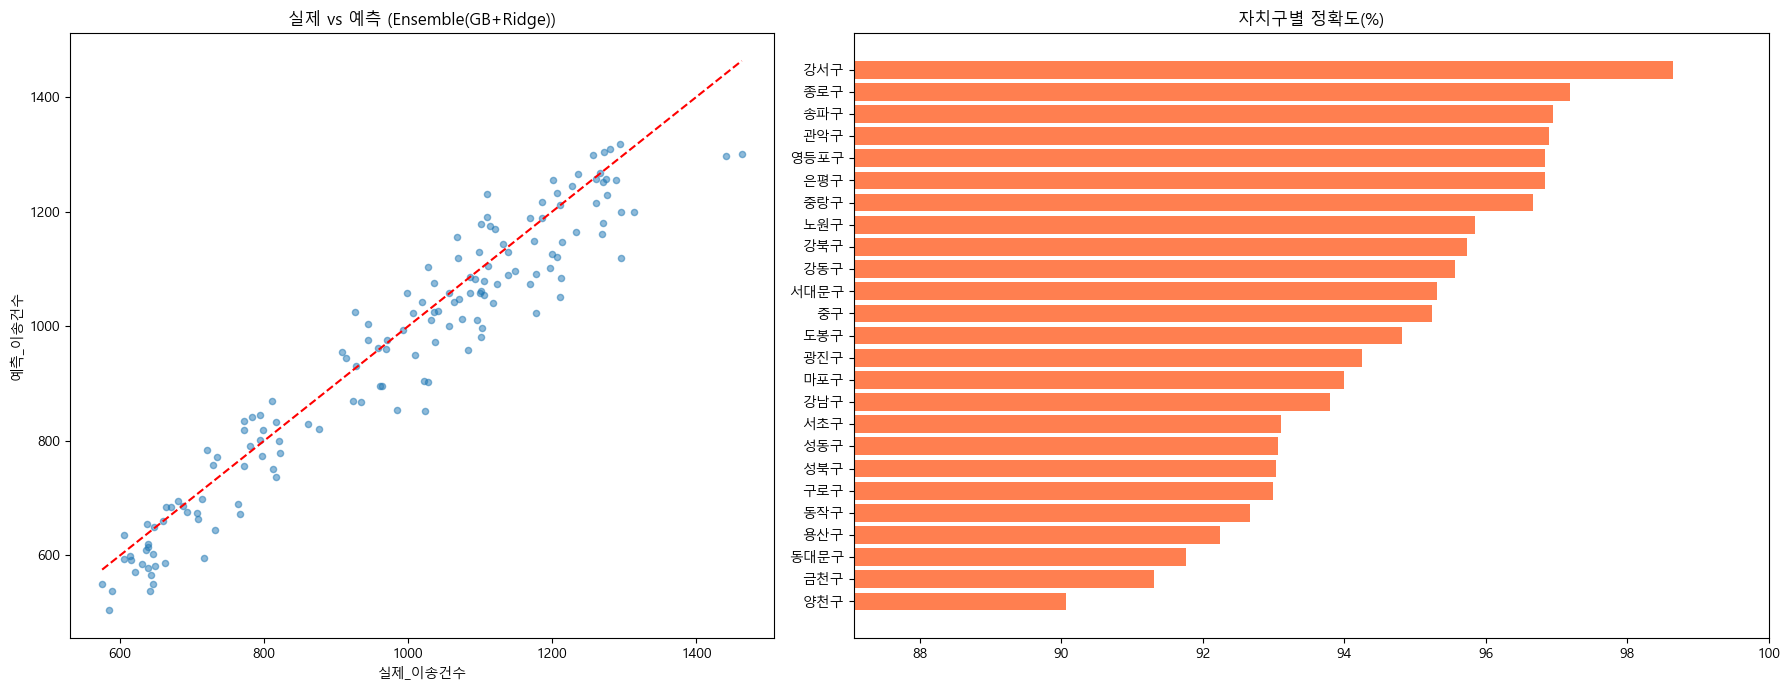

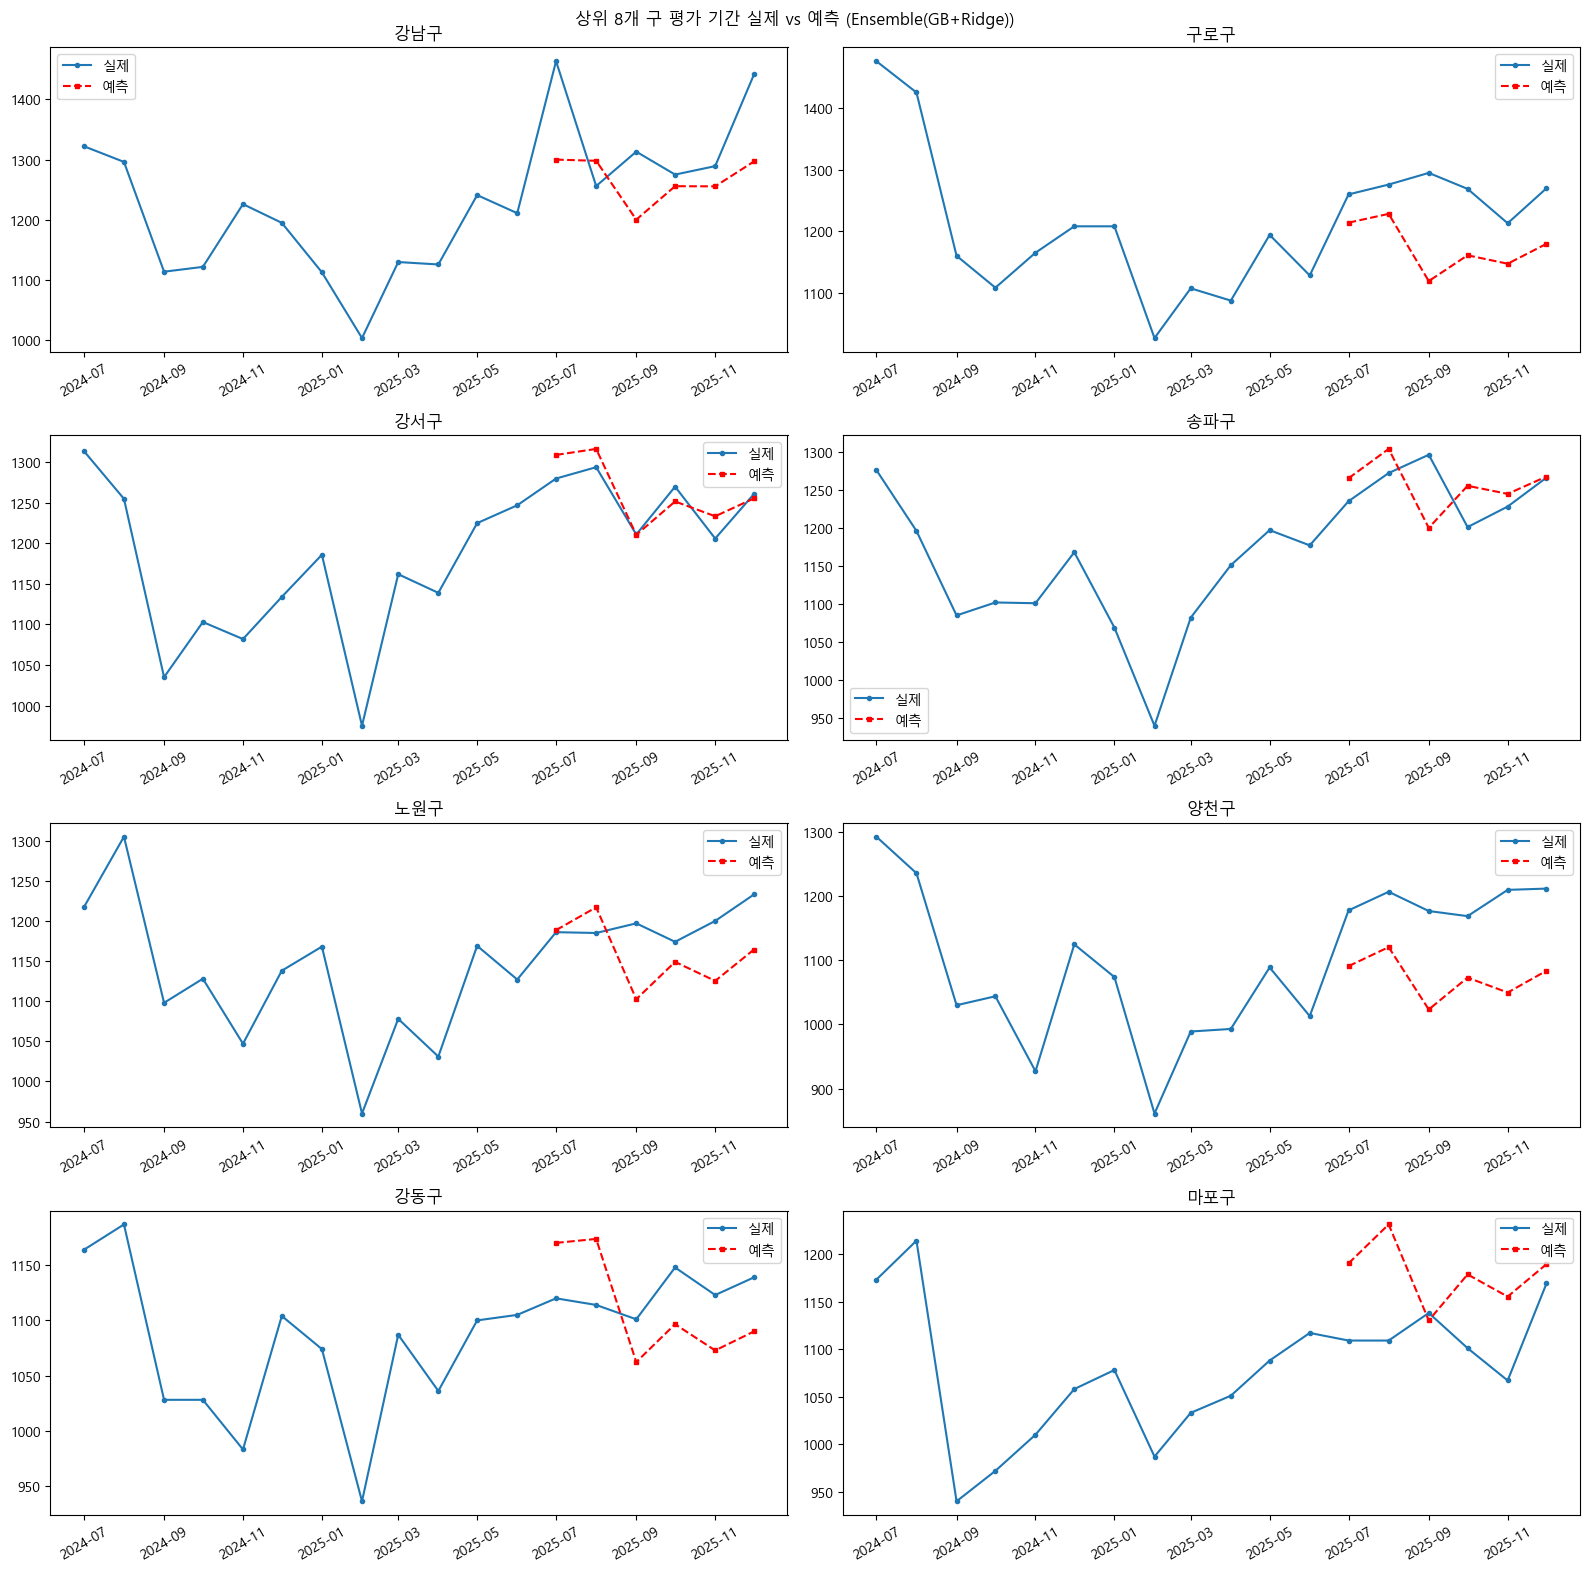

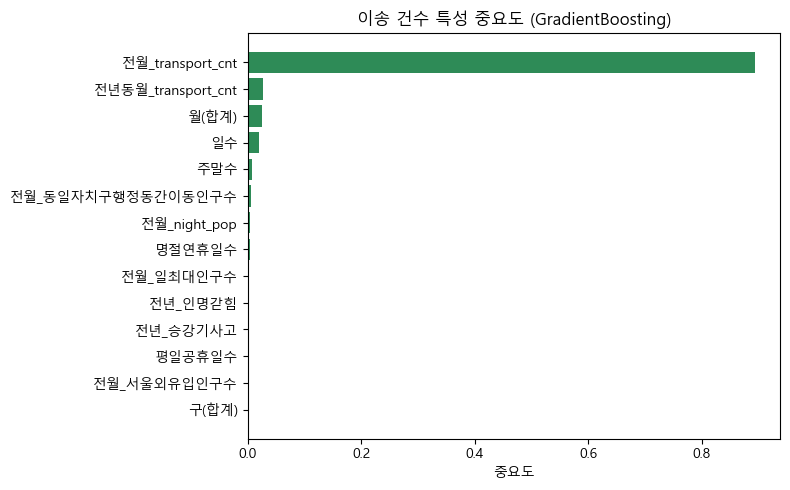

In [16]:
test_result = pd.DataFrame({'날짜': best_rec['ds'].dt.strftime('%Y-%m'), '지역구명': best_rec['District'],
                            '실제_이송건수': best_rec[target], '예측_이송건수': best_rec['예측'].round(0)})
test_result, gu_score = test_tables(test_result, '실제_이송건수', '예측_이송건수')
save_csv(test_result, 'transport_test_predictions.csv')
save_csv(gu_score.round(2), 'transport_test_scores_by_gu.csv')
plot_test_result(test_result, gu_score, '실제_이송건수', '예측_이송건수', best_name, 'transport_test_result.png')

top_gu = gu_score.nlargest(TOP_N, '실제평균')['지역구명'].tolist()
real = full.loc[full['ds'] >= test_start - pd.DateOffset(months=12), ['District', 'ds', target]]
real.columns = ['지역구명', '날짜', '값']
pred = best_rec[['District', 'ds', '예측']].set_axis(['지역구명', '날짜', '값'], axis=1)
plot_top_trend(real, pred, top_gu, f'상위 {TOP_N}개 구 평가 기간 실제 vs 예측 ({best_name})', 'transport_test_trend.png')

imp_bundle = bundles[best_name]
if best_name == ENSEMBLE_NAME:
    imp_bundle = imp_bundle['members'][ENSEMBLE_MEMBERS.index('GradientBoosting')]
elif not hasattr(imp_bundle['model'], 'feature_importances_'):
    imp_bundle = bundles['RandomForest']
imp = group_importance(imp_bundle, ['구_', '월_'])
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(imp, f'이송 건수 특성 중요도 ({imp_bundle["name"]})', ax)
save_fig('transport_importance.png')

## 4-4. 최종 모델 저장 · 구별 미래 예측
- 최종 모델 : 최고 모델을 전체 데이터로 다시 학습 → 저장 → 다시 불러와 예측
- 입력 : `transport_future.csv` (첫 달만 실제 전월 값, 이후 재귀 예측)
- 결과 csv : `transport_forecast_by_gu.csv` (예측월 · 지역구명 · 예측_이송건수)

예측월,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
지역구명,,,,,,
강남구,1349,1233,1283,1312,1400,1395
강동구,1100,997,1039,1053,1131,1122
강북구,992,904,936,948,1032,1024
강서구,1210,1088,1127,1146,1231,1215
관악구,1071,976,1027,1055,1152,1144
광진구,758,682,709,742,811,806
구로구,1217,1096,1147,1168,1257,1250
금천구,598,532,562,571,632,627
노원구,1169,1046,1084,1101,1190,1183


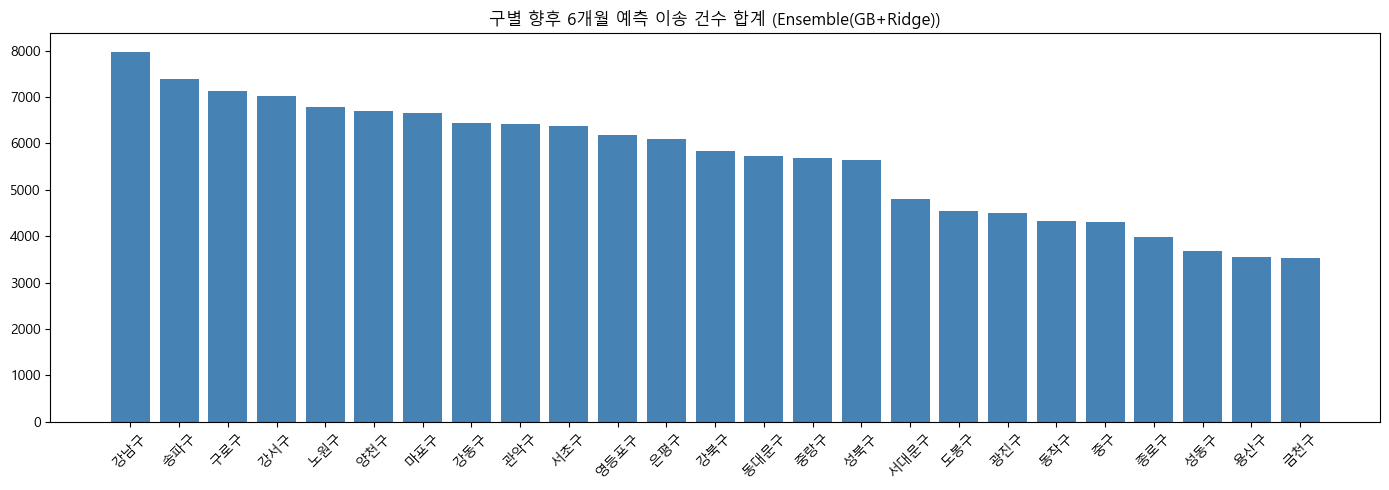

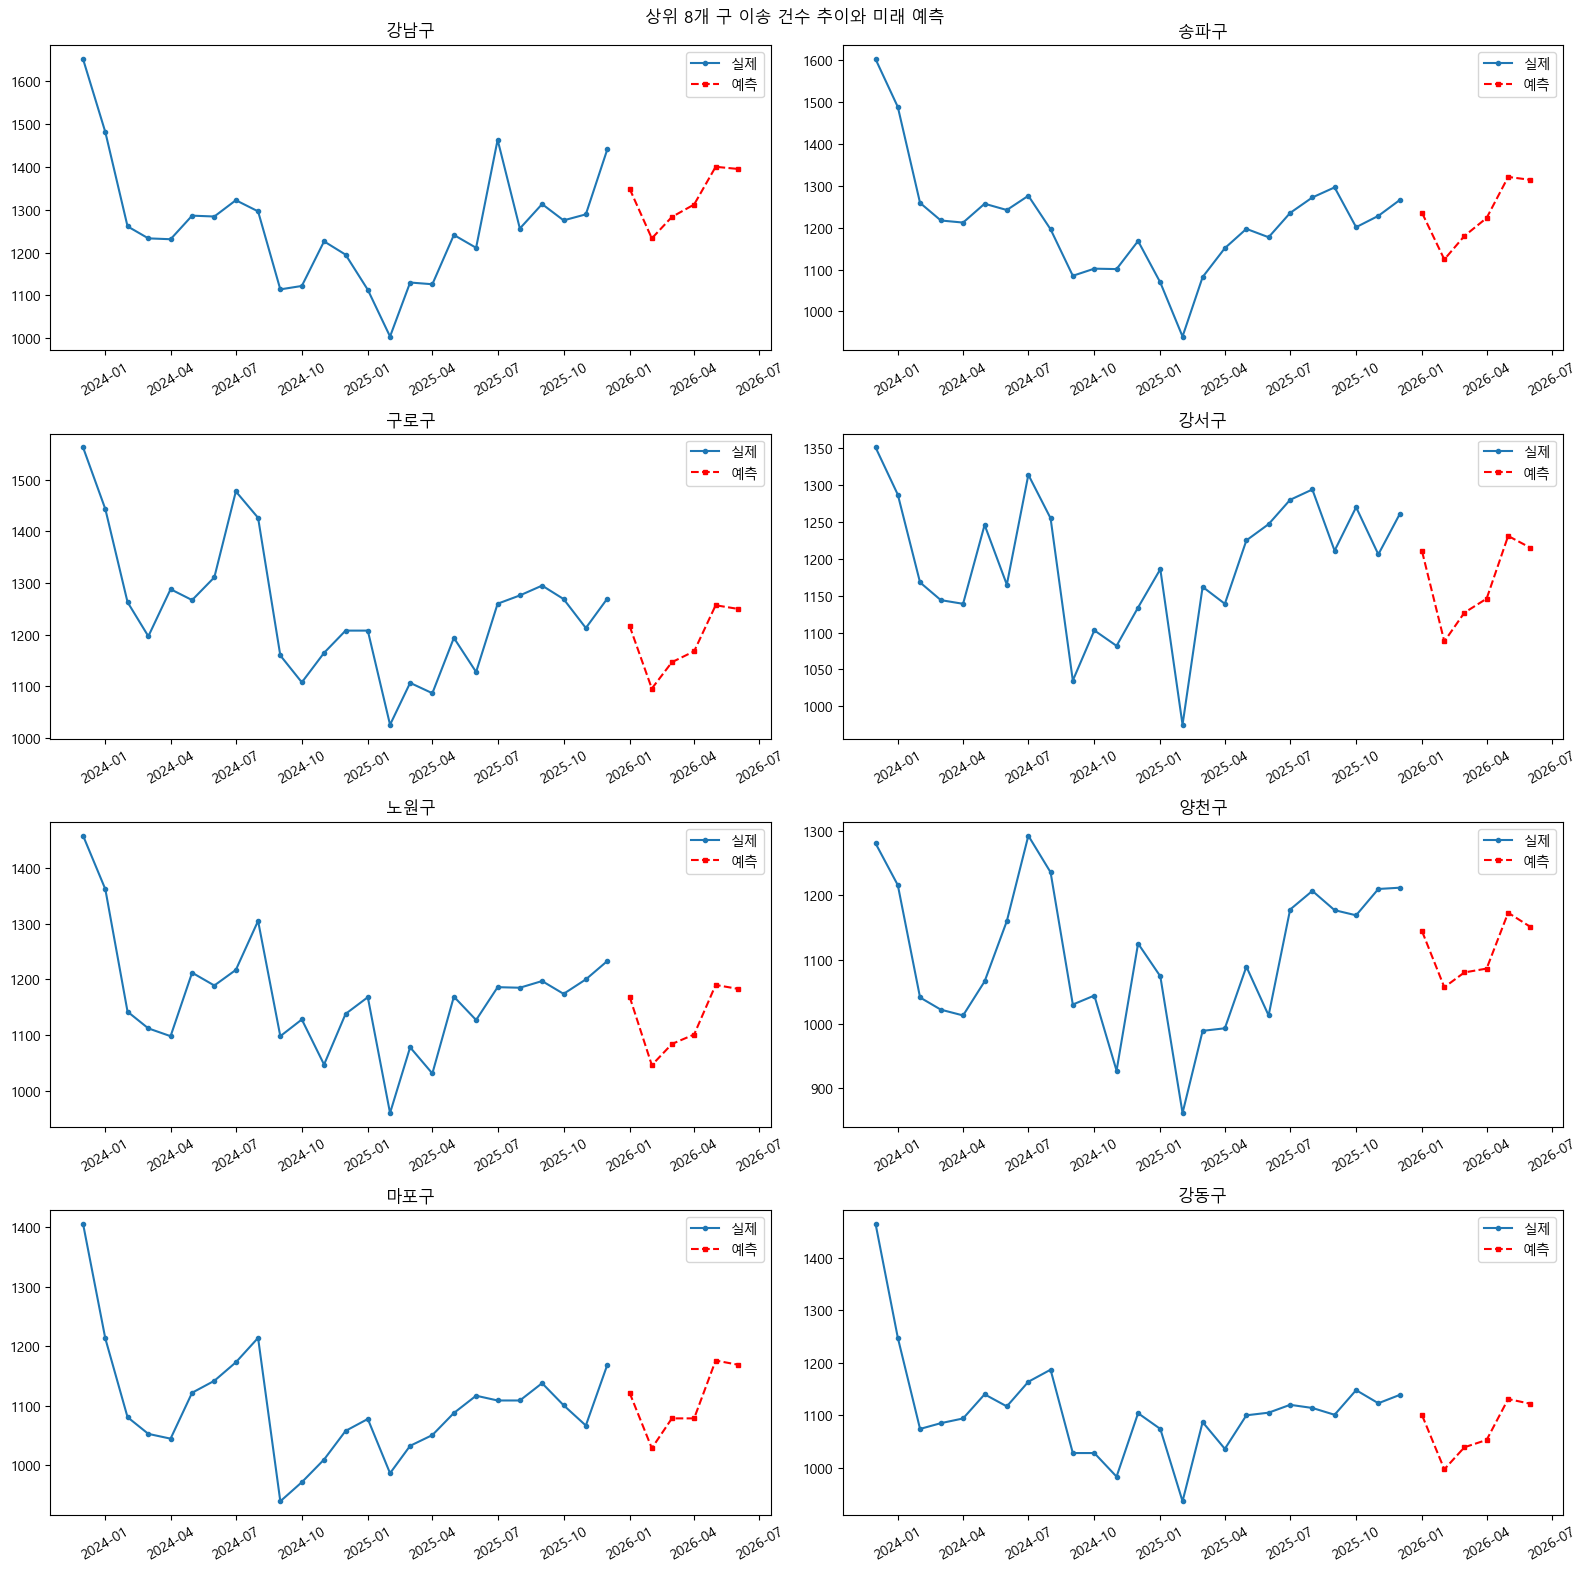

In [17]:
save_bundle(fit_transport(best_name, data, num_features, USE_DIFF_TARGET), 'transport')
fc = predict_months(load_bundle('transport'), future)
forecast = pd.DataFrame({'예측월': fc['ds'].dt.strftime('%Y-%m'), '지역구명': fc['District'],
                         '예측_이송건수': fc['예측'].round(0).astype(int), '사용모델': best_name,
                         '증감량예측': USE_DIFF_TARGET})
save_csv(forecast, 'transport_forecast_by_gu.csv')
display(forecast.pivot(index='지역구명', columns='예측월', values='예측_이송건수'))

gu_total = forecast.groupby('지역구명')['예측_이송건수'].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
plt.bar(gu_total.index, gu_total.values, color='steelblue')
plt.xticks(rotation=45)
plt.title(f'구별 향후 {forecast["예측월"].nunique()}개월 예측 이송 건수 합계 ({best_name})')
save_fig('transport_forecast_by_gu.png')

real = full.loc[full['ds'] >= full['ds'].max() - pd.DateOffset(months=24), ['District', 'ds', target]]
real.columns = ['지역구명', '날짜', '값']
pred = pd.DataFrame({'지역구명': forecast['지역구명'], '날짜': pd.to_datetime(forecast['예측월']),
                     '값': forecast['예측_이송건수']})
plot_top_trend(real, pred, gu_total.index[:TOP_N].tolist(), f'상위 {TOP_N}개 구 이송 건수 추이와 미래 예측',
               'transport_forecast_top.png')

---
# 5. 인구 밀집 예측 (자치구 × 일)

## 5-1. 데이터 · 요일 효과
- 정답 : `일최대인구수` / 숫자 특성 : 전처리에서 `선택`된 컬럼
- 요일·월 원-핫 : 숫자(0~6)로 두면 선형 모델이 "일요일 = 월요일 × 6"처럼 해석
- **날짜순 정렬** : DNN `validation_split`이 최근 기간을 쓰도록
- 요일 효과 : 구 평균으로 나눈 비율 (업무지구는 주말 감소, 주거지역은 변화 적음)

숫자 특성 : ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff', '주말여부'] / 입력 : (75825, 50)


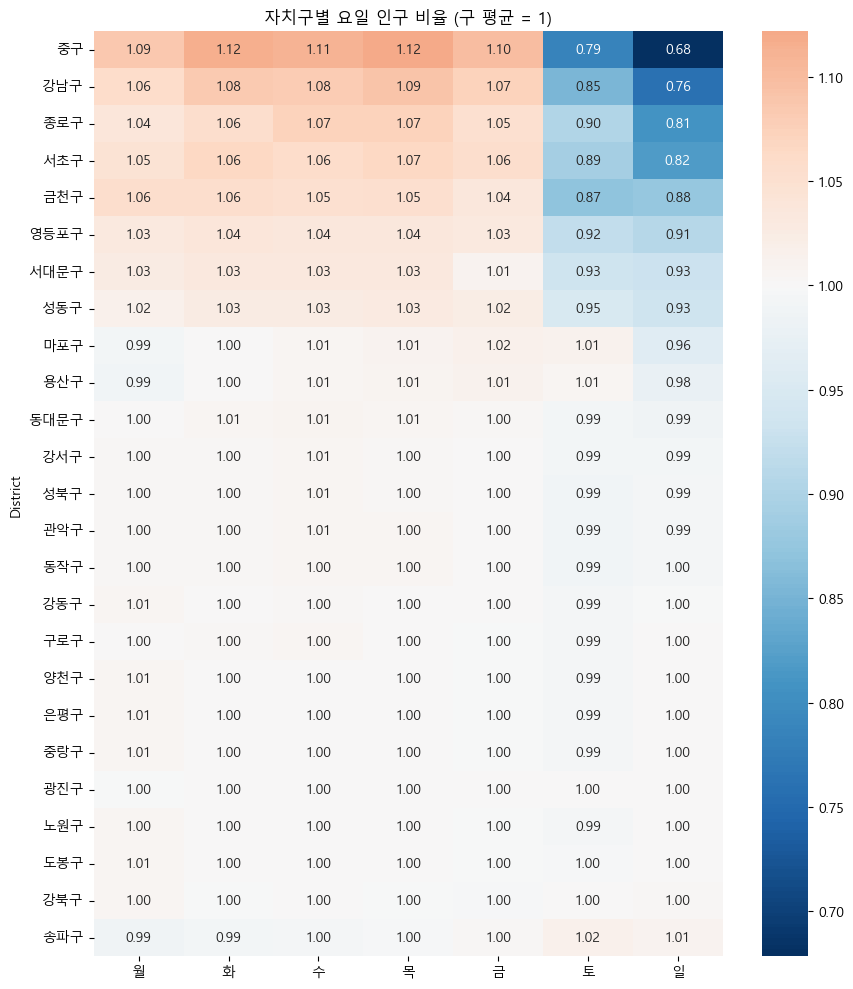

In [18]:
TARGET_POP = '일최대인구수'
pop = load_csv('population_selected.csv').sort_values(['ds', 'District']).reset_index(drop=True)
pop_info = load_csv('features_population.csv', dates=False)
pop['요일'] = pop['ds'].dt.dayofweek
pop['월'] = pop['ds'].dt.month
pop['주말여부'] = (pop['요일'] >= 5).astype(int)
pop_num = pop_info.loc[pop_info['결과'] == '선택', '컬럼'].tolist() + ['주말여부']

X_pop = make_X(pop, pop_num, POP_ONEHOT)
y_pop = pop[TARGET_POP]
print('숫자 특성 :', pop_num, '/ 입력 :', X_pop.shape)

day_ratio = pop.pivot_table(index='District', columns='요일', values=TARGET_POP)
day_ratio = day_ratio.div(day_ratio.mean(axis=1), axis=0)
day_ratio.columns = ['월', '화', '수', '목', '금', '토', '일']
plt.figure(figsize=(9, 10))
sns.heatmap(day_ratio.sort_values('일'), annot=True, fmt='.2f', cmap='RdBu_r', center=1)
plt.title('자치구별 요일 인구 비율 (구 평균 = 1)')
save_fig('population_weekday_by_gu.png')

## 5-2. 시간순 분할 · 모델 6종 학습
- 평가 : 마지막 1년 / 검증 : 그 앞 180일 / 학습 : 나머지
- 기준선 : 7일 전 같은 요일 값 그대로
- 약 7만 행 → 학습에 몇 분 소요

,모델,검증_정확도(%),평가_정확도(%),평가_R2,평가_MAE,평가_RMSE
0,RandomForest,98.589,98.163,0.986,8836.005,21081.660
1,GradientBoosting,98.356,97.970,0.986,9463.479,20994.535
2,DNN,98.077,97.246,0.980,12804.391,24586.054
3,기준선(7일 전 그대로),97.862,97.545,0.952,12015.489,38631.152
4,DecisionTree,97.855,97.479,0.978,11684.694,26195.496
5,Ridge,97.337,97.112,0.969,14036.455,30769.442
6,LinearRegression,97.335,97.110,0.969,14041.460,30769.501


최고 모델 (검증 기준) : RandomForest


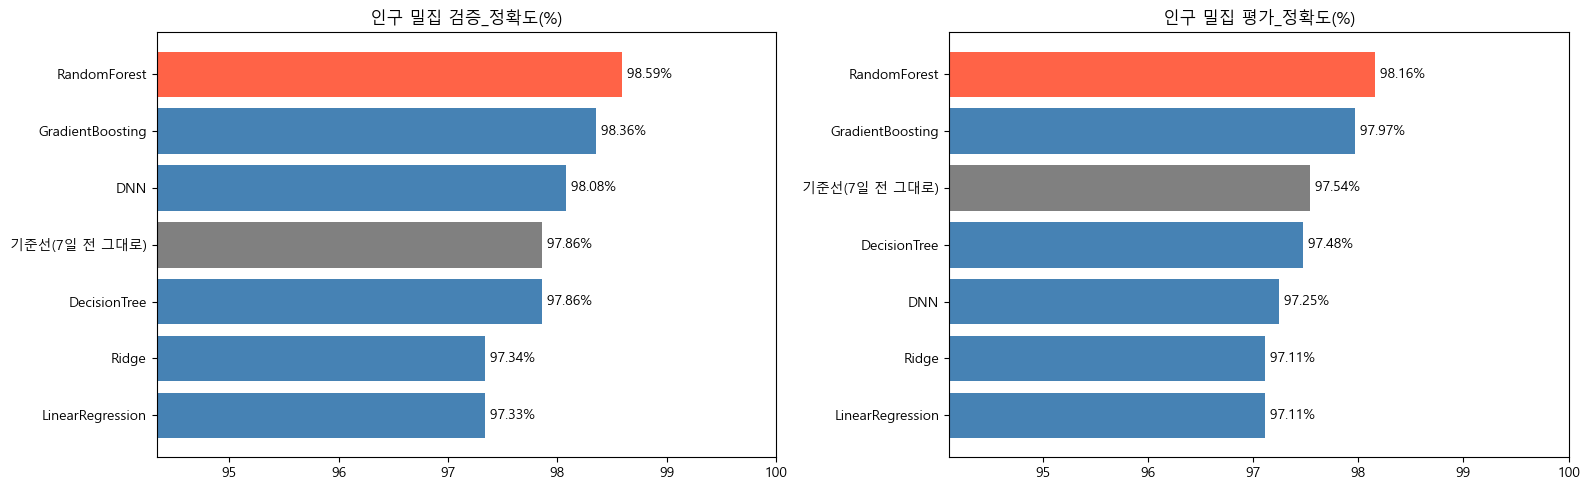

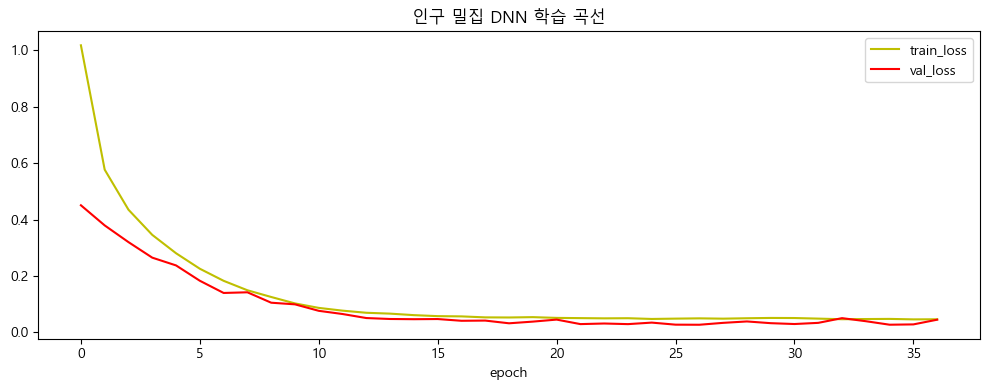

In [19]:
test_start_pop = pop['ds'].max() - pd.Timedelta(days=POP_TEST_DAYS - 1)
valid_start_pop = test_start_pop - pd.Timedelta(days=POP_VALID_DAYS)
tr, va = pop['ds'] < valid_start_pop, (pop['ds'] >= valid_start_pop) & (pop['ds'] < test_start_pop)
tv, te = pop['ds'] < test_start_pop, pop['ds'] >= test_start_pop


def pop_row(name, v, t):
    return {'모델': name, '검증_정확도(%)': v['정확도(%)'], '평가_정확도(%)': t['정확도(%)'],
            '평가_R2': t['R2'], '평가_MAE': t['MAE'], '평가_RMSE': t['RMSE']}


pop_scores, pop_bundles, pop_preds = [], {}, {}
for name in MODEL_NAMES:
    v = evaluate(y_pop[va], predict(fit_model(name, X_pop[tr], y_pop[tr], 'population'), X_pop[va]))
    pop_bundles[name] = fit_model(name, X_pop[tv], y_pop[tv], 'population')
    pop_preds[name] = predict(pop_bundles[name], X_pop[te])
    pop_scores.append(pop_row(name, v, evaluate(y_pop[te], pop_preds[name])))

pop_scores.append(pop_row('기준선(7일 전 그대로)', evaluate(y_pop[va], pop.loc[va, '7일전_일최대인구수']),
                          evaluate(y_pop[te], pop.loc[te, '7일전_일최대인구수'])))
pop_score_df = pd.DataFrame(pop_scores).sort_values('검증_정확도(%)', ascending=False).reset_index(drop=True)
save_csv(pop_score_df, 'population_model_scores.csv')
display(pop_score_df.round(3))

pop_best = pop_score_df[pop_score_df['모델'].isin(MODEL_NAMES)].iloc[0]['모델']
print('최고 모델 (검증 기준) :', pop_best)
plot_scores(pop_score_df, ['검증_정확도(%)', '평가_정확도(%)'], pop_best, '인구 밀집', 'population_model_scores.png')
plot_history(pop_bundles['DNN']['history'], '인구 밀집 DNN 학습 곡선', 'population_dnn_history.png')

## 5-3. 평가 결과 · 특성 중요도 · 최종 모델 저장
- 오차가 큰 날 확인 : 공휴일·명절이 많으면 공휴일 컬럼 추가 검토
- 원-핫 컬럼 합산 : `구_`, `요일_`, `월_`
- 최종 모델 : 전체 기간으로 다시 학습 후 저장

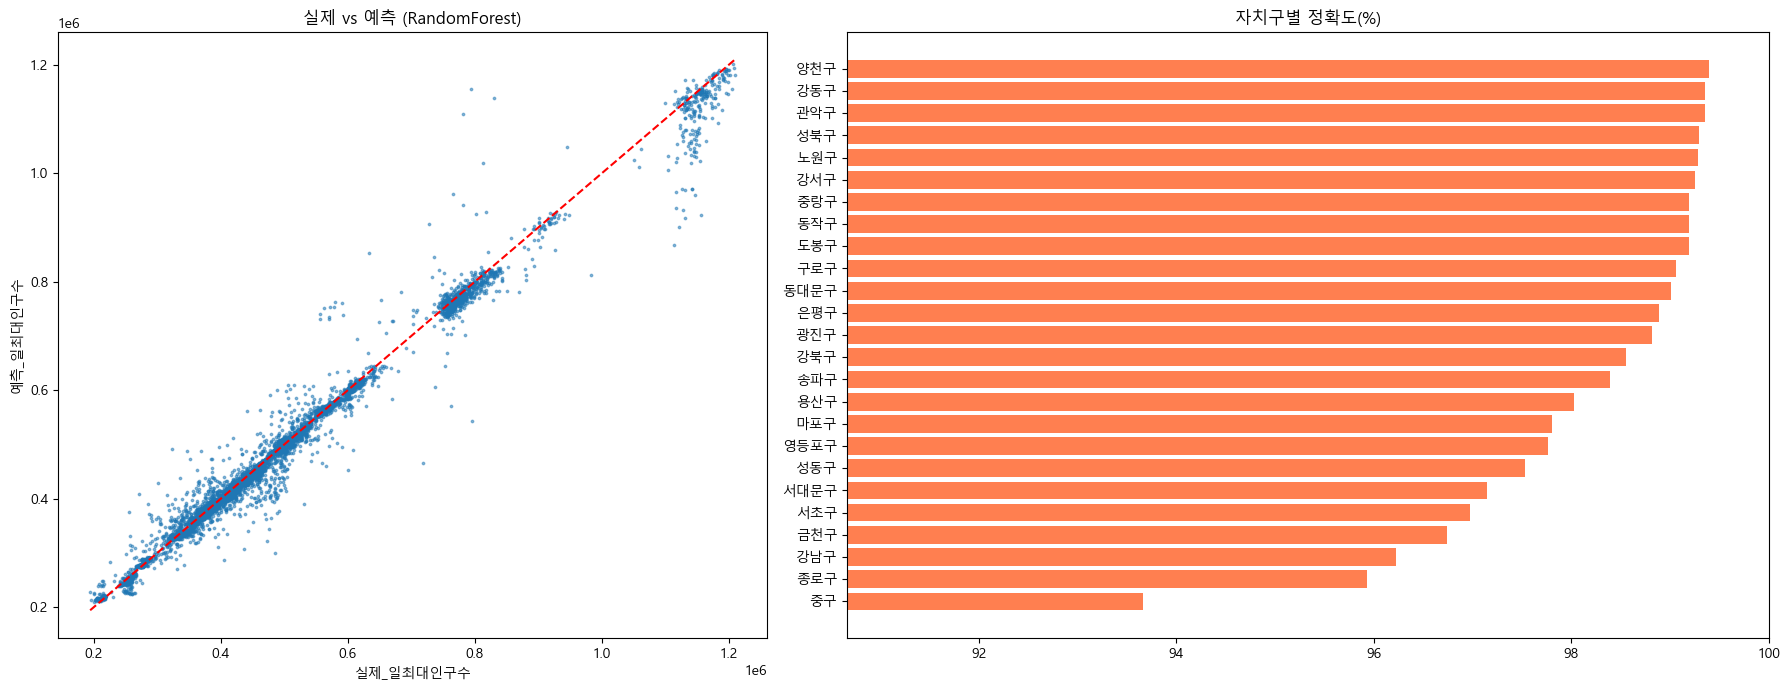

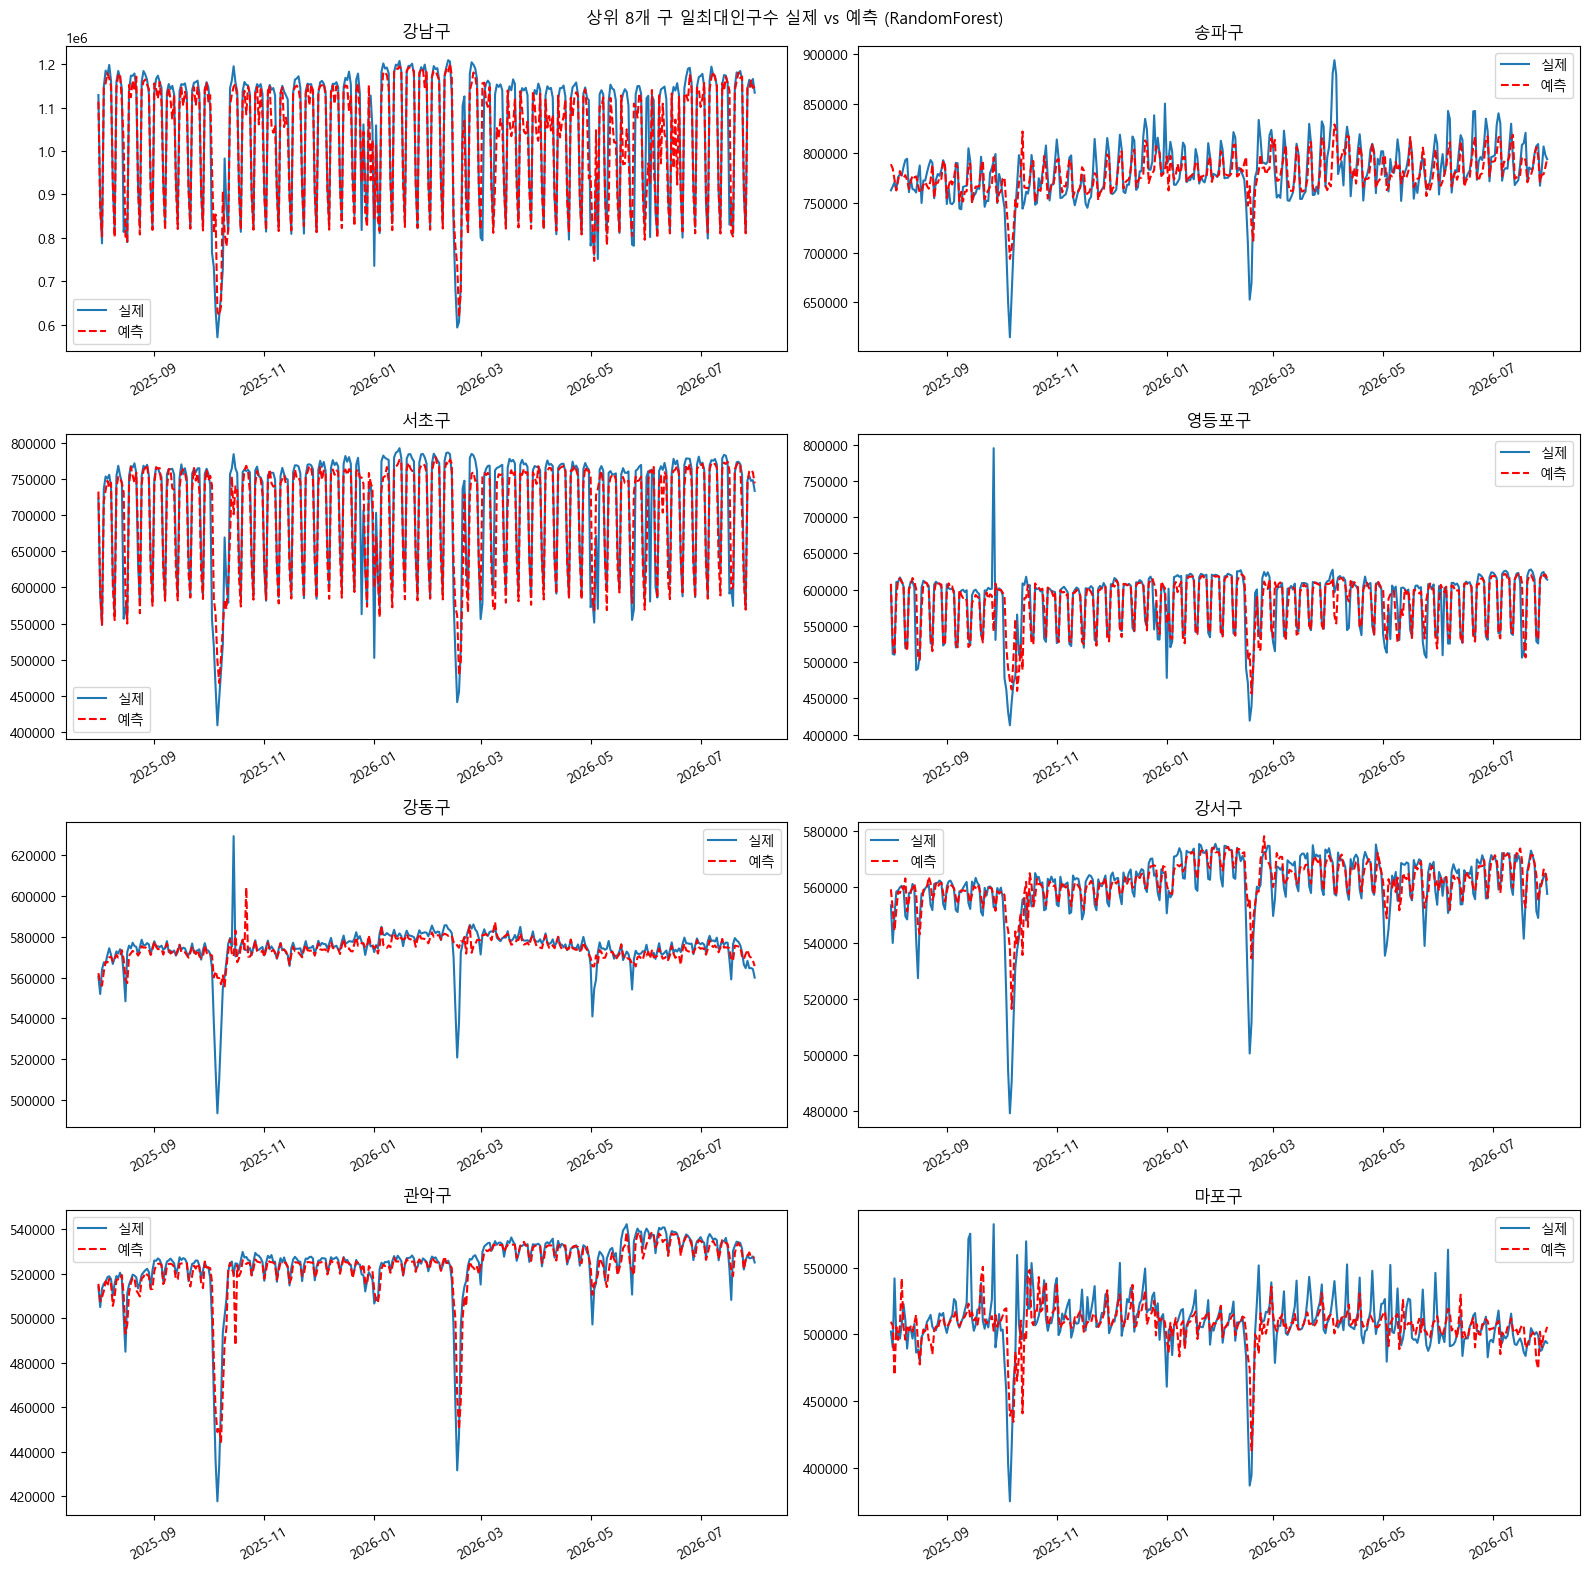

,오차율 상위 10일 (%)
날짜,
2025-10-06,13.07
2026-02-16,12.36
2025-10-15,12.06
2025-10-05,11.31
2025-10-03,9.19
2025-10-04,9.02
2026-01-01,8.24
2026-03-02,8.02
2026-06-03,7.97


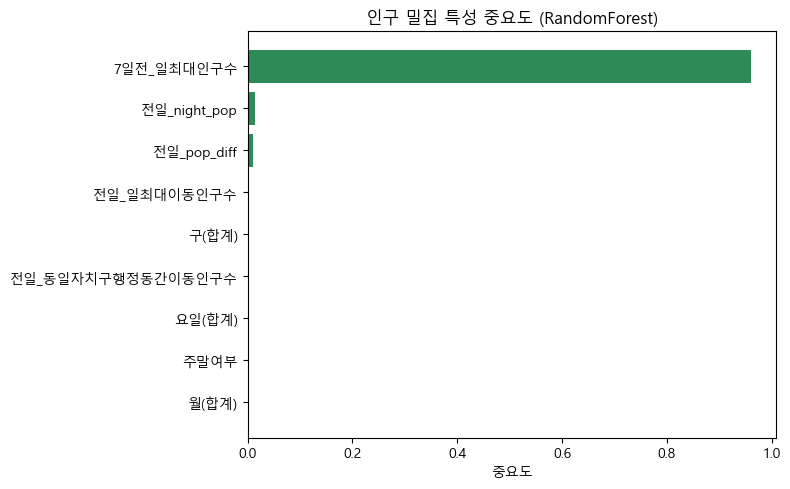

In [20]:
pop_result = pd.DataFrame({'날짜': pop.loc[te, 'ds'].dt.strftime('%Y-%m-%d').values,
                           '지역구명': pop.loc[te, 'District'].values,
                           '실제_일최대인구수': y_pop[te].values.round(0),
                           '예측_일최대인구수': pop_preds[pop_best].round(0)})
pop_result, pop_gu_score = test_tables(pop_result, '실제_일최대인구수', '예측_일최대인구수')
save_csv(pop_result, 'population_test_predictions.csv')
save_csv(pop_gu_score.round(2), 'population_test_scores_by_gu.csv')
plot_test_result(pop_result, pop_gu_score, '실제_일최대인구수', '예측_일최대인구수', pop_best,
                 'population_test_result.png', s=3)

top_gu = pop_gu_score.nlargest(TOP_N, '실제평균')['지역구명'].tolist()
real = pd.DataFrame({'지역구명': pop_result['지역구명'], '날짜': pd.to_datetime(pop_result['날짜']),
                     '값': pop_result['실제_일최대인구수']})
plot_top_trend(real, real.assign(값=pop_result['예측_일최대인구수']), top_gu,
               f'상위 {TOP_N}개 구 일최대인구수 실제 vs 예측 ({pop_best})', 'population_trend.png', marker=None)
display(pop_result.groupby('날짜')['오차율(%)'].mean().nlargest(10).round(2).to_frame('오차율 상위 10일 (%)'))

fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(group_importance(pop_bundles['RandomForest'], ['구_', '요일_', '월_']),
                '인구 밀집 특성 중요도 (RandomForest)', ax)
save_fig('population_importance.png')

save_bundle(fit_model(pop_best, X_pop, y_pop, 'population'), 'population')

---
# 6. 결과 요약 (자동 출력)

In [21]:
c = rel_corr.loc[KEY_POP]
print(f'[연관성] 대표 인구 {KEY_POP} : 자치구 간 상관 {c["자치구간"]:.2f} / 자치구 내 상관 {c["자치구내"]:.2f}')
print(f'  이송률 최고/최저 {rate_ratio:.1f}배 / 계절 성분 상관 {decomp_corr["계절_상관"].mean():.2f}')
print(f'[인구 특성] E - D = {pop_gain:+.3f}%p → 사용 {USE_POP}')
print(f'[개선 실험] 채택 설정 {best_set} (달력 {USE_CALENDAR}, 증감량 {USE_DIFF_TARGET})')
print(f'[이송 건수] 최고 모델 {best_name} / 앙상블 오차 상관 {err_corr:.3f}')
print(f'[인구 밀집] 최고 모델 {pop_best}')
print('[결과 폴더] ->', RESULT_DIR)

[연관성] 대표 인구 night_pop : 자치구 간 상관 0.80 / 자치구 내 상관 0.23
  이송률 최고/최저 1.9배 / 계절 성분 상관 -0.40
[인구 특성] E - D = -0.177%p → 사용 False
[개선 실험] 채택 설정 달력 (달력 True, 증감량 False)
[이송 건수] 최고 모델 Ensemble(GB+Ridge) / 앙상블 오차 상관 0.500
[인구 밀집] 최고 모델 RandomForest
[결과 폴더] -> C:\ai\source\09_Project\cheolhyeon_jo\ml_result


최종 모델은 **GradientBoosting + Ridge 앙상블(달력 특성 포함)** 로, 향후 6개월 연속 예측에서 **평가 정확도 94.6%** 를 기록했습니다.

**정확도를 높이기 위해 시도한 것**
- 효과가 컸던 시도 : 앙상블(평가 MAE 20% 감소), 달력 특성(검증 +0.73%p)
- 최종 성과 : 6개월 예측 평가 정확도 94.6%, 기준선 대비 MAE 22% 감소
- 제외 : 증감량 예측(달력보다 낮음), 달력 특성 및 증감량 동시 적용(급락), PCA·RFE·순서형 모델(구조·데이터 부적합)